# **Disturbance models**

## Research questions
1. What are the ideal settings for a drone flight to ensure it doesn't cause any disruption to lions?
2. How does social context affect lions’ response to drones?

### Hypothesis
1. **Higher altitude = less disturbance**, i.e. less flee/fear, less exploratory and more calm/inactive responses;
   In addition to these points, pride ID might influence the behavioral responses
2. **There are not cubs in the pride OR during the tests = decreased sensitivity to drone flights**, i.e. less flee/fear, less exploratory and more calm/inactive responses


In [1]:
# Packages

import pymc as pm
import numpy as np
import arviz as az
import bambi as bmb
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter, MaxNLocator
import pyperclip as pc

import seaborn as sns



In [2]:
# Upload dataset

file_path = 'ToleranceTest_MasterDoc.xlsx'

df = pd.read_excel(file_path, engine='openpyxl')

print(df.head())
print(df.columns.tolist())

  Test_ID       Date Species  Altitude      Time BF_Distance  \
0    AJ01 2024-11-07    Lion        60  10:33:00          38   
1    AJ02 2024-11-07    Lion       100  11:35:00          35   
2    AJ03 2024-11-07    Lion        40  11:50:00          35   
3    AJ04 2024-11-08    Lion       120  17:15:00          18   
4    AJ05 2024-11-08    Lion       100  17:47:00          14   

   BF_Distance_averaged BF_Agonistic BF_Aggressive/Flee BF_Fear  ...  \
0                    38            N                  N       N  ...   
1                    35            N                  N       N  ...   
2                    35            N                  N       N  ...   
3                    18          NaN                  N       N  ...   
4                    14          NaN                  N       N  ...   

  Drone_N_M Drone_N_c DroneVIDEO_N_Individual DroneVIDEO_N_F DroneVIDEO_N_M  \
0         2         3                       6              1              2   
1         2         3   

# **Exploratory analysis 1 - general plotting**

In the below script, there are exploratory plottings of data before any data manipulation. These analyses give an overview of the data collected and help the design of further analyses.

[Other notebook](./first_plotting_tolerance.ipynb)

# **Data preparation**

In the following cells, data are manipulated in order to be ready to feed models following the research questions' objectives and expected hypothesis.

**CELL01**

- data are filtered by species to keep only data that refers to lion;
- a column called 'Pride_ID', which refers to the name of each pride tested, is created from the original 'Test_ID' column (each Test ID contains the initials of a pride name);
- 'Date' data are transformed into datetime format, and a new column called 'Week' is created;
- Some of the behavioral columns are grouped, specifically:
  1. 'Agonistic', 'Flee', 'Fear' and 'Stereotypic' behaviors are grouped into 'Flee/Fear'
  2. 'Calm' and 'Inactive' are grouped into 'Calm/Inactive'
  3. 'Marking', 'Maintenance', 'Feeding', 'Vocalization' and 'Affiliative_Reproductive' are grouped into 'Feeding/Affiliative/Mating'
- 'Altitude' is transformed to a continuous predictor (log transformed and standardized)

Note that 'BF' stands for *Before Flight* behaviors and 'AF' stands for *After Flight* behaviors 

In [3]:
# CELL01

# data preparation 

data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']

data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# ADD: Cluster_ID as Pride_ID + 'x' + DDMM
data['Cluster_ID'] = data['Pride_ID'].astype(str) + 'x' + data['Date'].dt.strftime('%d%m')

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Define a function to convert positive sums to 1
def convert_to_binary(value):
    return 1 if value > 0 else value

# Combine columns as specified and apply the conversion function
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['BF_Calm/Inactive'] = data[['BF_Calm', 'BF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization', 'BF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['AF_Calm/Inactive'] = data[['AF_Calm', 'AF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating']])

# --- Altitude Transformation ---
data['log_altitude'] = np.log(data['Altitude'])
data['z_log_altitude'] = (data['log_altitude'] - data['log_altitude'].mean()) / data['log_altitude'].std()

data = data[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Exploratory',
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Exploratory','Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'log_altitude', 'z_log_altitude', 'prides', 'Pride_ID', 'Cluster_ID']]

print(data)
print(data.columns.tolist())


         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Calm/Inactive  BF_Feeding/Affiliative/Mating  \
0            0.0                 1                              0   
1            0.0                 1                              0   
2            0.0                 1                              0   
3            0.0                 1                              0   
4            0.0                 1                              0   
..           ...               ...                            ...   
64           0.0                 1                              0   
65           0.0                 1                              0   
66           0.0                 1                              0   
67           0.0                 1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46906/4019063468.py:43: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))


**CELL02**

We want the dataset to be reshaped such that every behavior observed coincides with a row (an observation). Moreover, we want to create a new binary column for the behavioral observation to be classified as referring to *Before Flight* (=0) or *After Flight* (=1). This latest will be named *before_after* and eventually used as a predictor in our models.



In [4]:
# CELL02

def melt_behavior_data(data, prefix):
    behavior_columns = [
        f'{prefix}_Flee/Fear', f'{prefix}_Calm/Inactive', f'{prefix}_Feeding/Affiliative/Mating', f'{prefix}_Loc',  f'{prefix}_Exploratory'
    ]
    # Include 'Pride_with_cubs' and 'DroneVIDEO_N_c' in id_vars to retain them
    melted_data = data.melt(
        id_vars=['Test_ID', 'Date', 'Species', 'Altitude','z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides', 'Pride_ID', 'Cluster_ID'],
        value_vars=behavior_columns,
        var_name='behavior_type',
        value_name='behavior_count'
    )
    melted_data['before_after'] = 0 if prefix == 'BF' else 1
    melted_data['behavior_type'] = melted_data['behavior_type'].str.replace(f'{prefix}_', '')
    return melted_data[melted_data['behavior_count'] > 0]

# Melt the data for 'before' and 'after'
before_data = melt_behavior_data(data, 'BF')
after_data = melt_behavior_data(data, 'AF')

# Concatenate the melted data
transformed_data = pd.concat([before_data, after_data], ignore_index=True)

# Use z_log_altitude only for 'after' observations
transformed_data.loc[transformed_data['before_after'] == 0, 'z_log_altitude'] = np.nan
transformed_data['z_log_altitude'].fillna(0, inplace=True)

# Select relevant columns
transformed_data = transformed_data[['Test_ID', 'Date', 'Species', 'Altitude', 'before_after', 'behavior_type', 'z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides','Pride_ID', 'Cluster_ID']]

# Display the resulting DataFrame
print(transformed_data)

    Test_ID       Date Species  Altitude  before_after  behavior_type  \
0      WA03 2024-11-12    Lion        40             0      Flee/Fear   
1      AJ01 2024-11-07    Lion        60             0  Calm/Inactive   
2      AJ02 2024-11-07    Lion       100             0  Calm/Inactive   
3      AJ03 2024-11-07    Lion        40             0  Calm/Inactive   
4      AJ04 2024-11-08    Lion       120             0  Calm/Inactive   
..      ...        ...     ...       ...           ...            ...   
264    WA09 2024-11-23    Lion        20             1    Exploratory   
265    WA10 2024-11-25    Lion       120             1    Exploratory   
266    WA11 2024-11-25    Lion        60             1    Exploratory   
267    WA12 2024-11-25    Lion        80             1    Exploratory   
268    WA13 2024-11-25    Lion        40             1    Exploratory   

     z_log_altitude  Pride_with_cubs  DroneVIDEO_N_c   prides Pride_ID  \
0          0.000000                1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46906/1637250494.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transformed_data['z_log_altitude'].fillna(0, inplace=True)


**CELL03**

Now our dataset has the right shape but we want to add an extra variable to it. From the original dataset we have a column called 'Pride_with_cubs' that tells us, for every flight test, if the pride tested had cubs or not. We also have a column called 'DroneVIDEO_N_c' which has the count of cubs during the test. We want to combine the information from these two columns  to have a new one that tells us if:
1. the pride has no cubs (=0);
2. the pride has cubs but they are not present during the test (=1);
3. the pride has cubs and they're present during the test (=2).

This is because we want to evaluate if there's an increase in lion sensitivity towards drones due exclusively to the presence of cubs during the flight or because the pride has cubs in general and so it displays higher alertness even when the cubs are not physically close to them.

This new column will be called 'Cubs_presence' and will be used in models labeled as 'advanced social context' since it contains more details of the social context involved rather than just the basic information of a pride with or without cubs.

In [5]:
# CELL03

# Create a categorical column 'Cubs_presence' where:
# 0=pride has no cubs, 1=pride has cubs but they're not present during the test, 2=pride has cubs and they're present during the test

# Create the new column with priority logic
transformed_data["Cubs_presence"] = np.where(transformed_data["DroneVIDEO_N_c"] != 0, 2, transformed_data["Pride_with_cubs"])

# Delete extra columns
transformed_data = transformed_data.drop(["DroneVIDEO_N_c"], axis=1)

# Display the first few rows to verify the changes
print(transformed_data)


    Test_ID       Date Species  Altitude  before_after  behavior_type  \
0      WA03 2024-11-12    Lion        40             0      Flee/Fear   
1      AJ01 2024-11-07    Lion        60             0  Calm/Inactive   
2      AJ02 2024-11-07    Lion       100             0  Calm/Inactive   
3      AJ03 2024-11-07    Lion        40             0  Calm/Inactive   
4      AJ04 2024-11-08    Lion       120             0  Calm/Inactive   
..      ...        ...     ...       ...           ...            ...   
264    WA09 2024-11-23    Lion        20             1    Exploratory   
265    WA10 2024-11-25    Lion       120             1    Exploratory   
266    WA11 2024-11-25    Lion        60             1    Exploratory   
267    WA12 2024-11-25    Lion        80             1    Exploratory   
268    WA13 2024-11-25    Lion        40             1    Exploratory   

     z_log_altitude  Pride_with_cubs   prides Pride_ID Cluster_ID  \
0          0.000000                1  Wanjiku       WA

# **Exploratory analysis 2 - plotting of input/output variables**

In this section, we will plot the variables shaped in the previous section ('Data preparation - CELL01/CELL02/CELL03'). In particular, we will plot the categorical *behavior_type* against the binary predictor *before_after*, the continuous predictor *z_log_altitude*, the binary predictor *Pride_with_cubs* and the categorical predictor *Cubs_presence*. This will help us to overview the distribution of the output and how it is affected by the input variables:

1. Before and after flight state
2. Altitude
3. Social context (= pride with or without cubs)
4. Advanced social context (= pride with or without cubs and cubs present or not during the test)

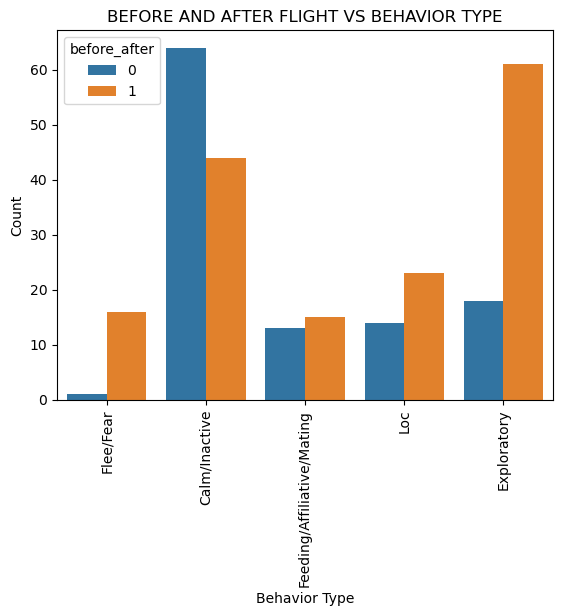

In [6]:
# 1. BEFORE AND AFTER FLIGHT VS BEHAVIOR TYPE

# Create the side-by-side bar chart
sns.countplot(x='behavior_type', hue='before_after', data=transformed_data)

# Add title and labels
plt.title('BEFORE AND AFTER FLIGHT VS BEHAVIOR TYPE')
plt.xticks(rotation=90)
plt.xlabel('Behavior Type')
plt.ylabel('Count')

# Show the plot
plt.show()

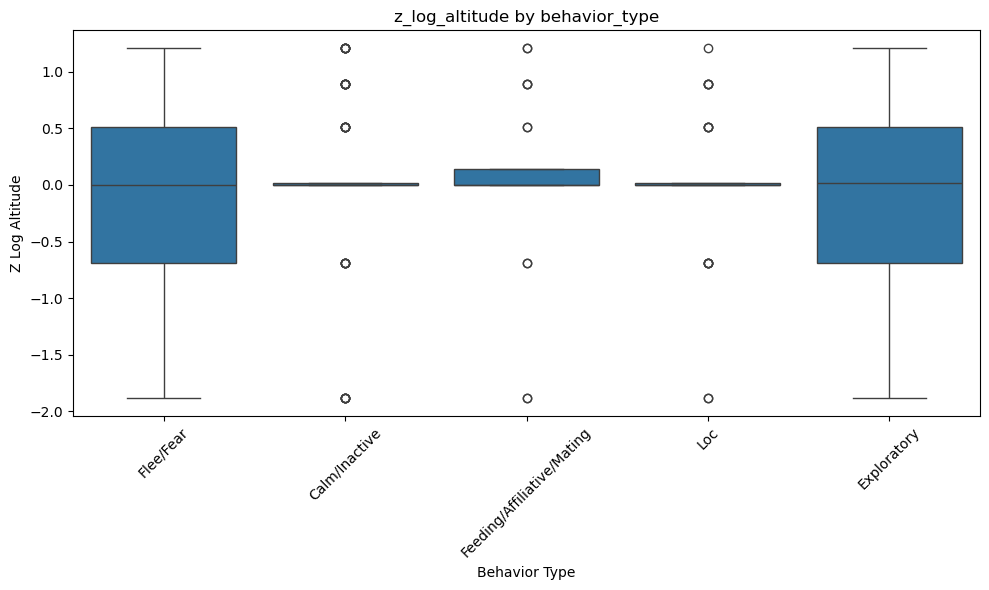

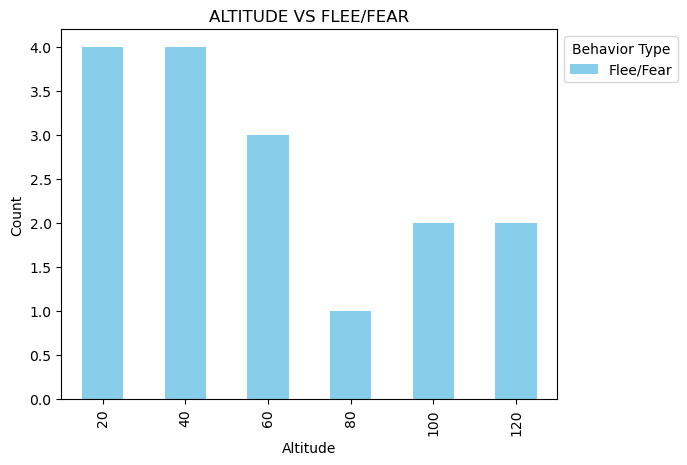

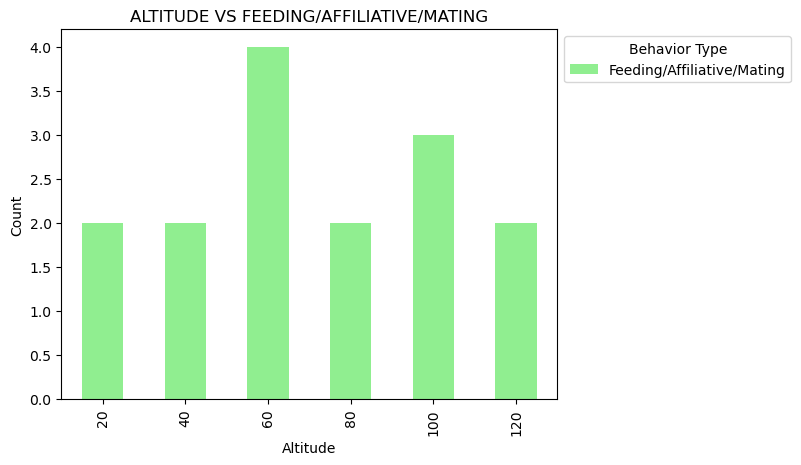

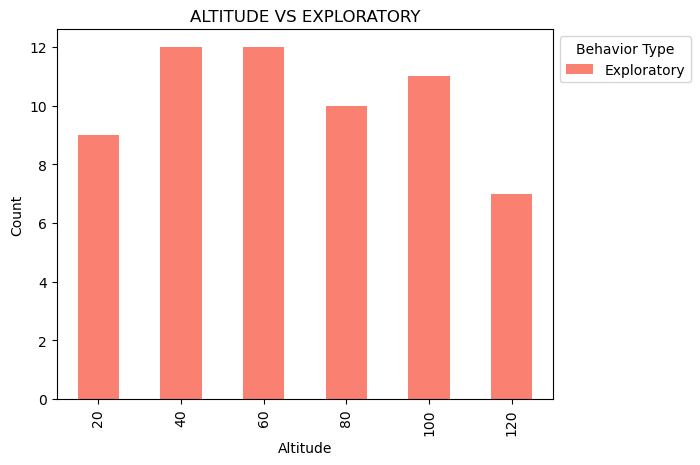

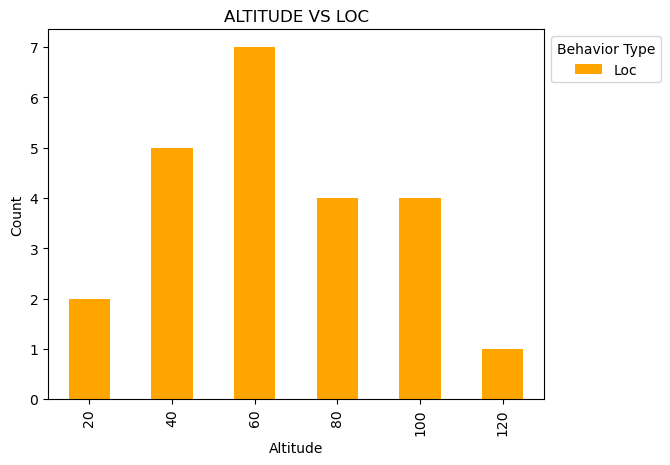

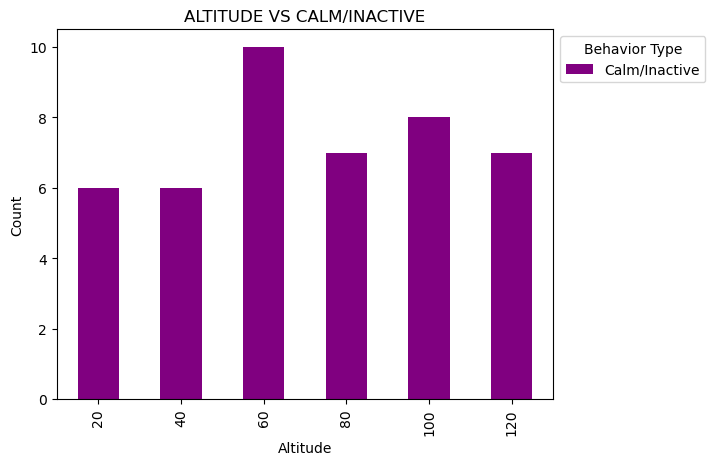

In [7]:
# 2. ALTITUDE VS BEHAVIOR TYPE

# Assuming transformed_data is a pandas DataFrame
# transformed_data = pd.read_csv('your_data.csv')  # Load your dataset if not already loaded

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='behavior_type', y='z_log_altitude', data=transformed_data)

# Add title and labels
plt.title('z_log_altitude by behavior_type')
plt.xlabel('Behavior Type')
plt.ylabel('Z Log Altitude')

# Show the plot
plt.xticks(rotation=45)  # Rotate x labels if needed
plt.tight_layout()       # Adjust layout to fit everything
plt.show()

# Assuming 'transformed_data' is your DataFrame
data = transformed_data[transformed_data['before_after'] == 1]

# List of behavior types
behavior_types = ['Flee/Fear', 'Feeding/Affiliative/Mating', 'Exploratory', 'Loc', 'Calm/Inactive']

# Define a color for each behavior type
colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'purple']

# Plot a graph for each behavior type
for behavior, color in zip(behavior_types, colors):
    # Filter data for the current behavior type
    behavior_data = data[data['behavior_type'] == behavior]
    
    # Create a contingency table
    contingency_table = pd.crosstab(behavior_data['Altitude'], behavior_data['behavior_type'])
    
    # Plot a bar chart with a specific color
    contingency_table.plot(kind='bar', stacked=True, color=color)
    
    plt.title(f'ALTITUDE VS {behavior.upper()}')
    plt.xlabel('Altitude')
    plt.ylabel('Count')
    plt.legend(title='Behavior Type', loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

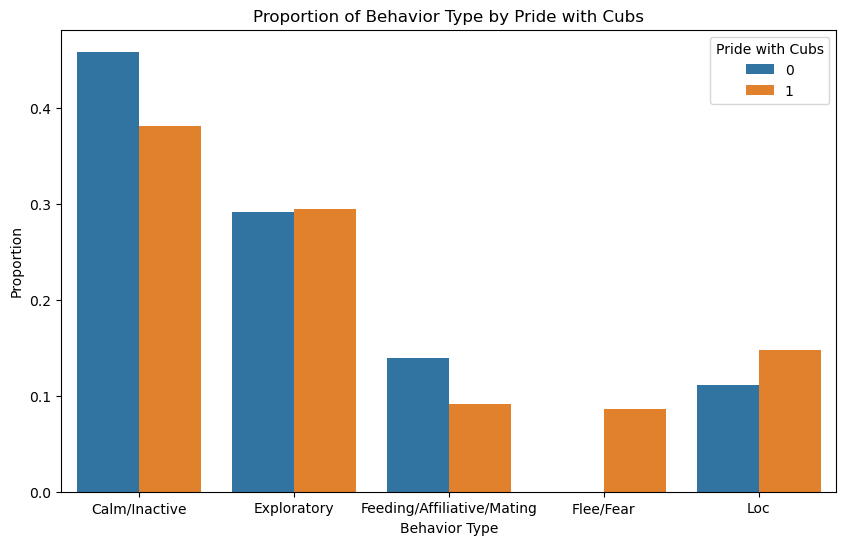

In [8]:
# 3. SOCIAL CONTEXT VS BEHAVIOR TYPE
# SOCIAL CONTEXT: WITH (=1) AND WITHOUT (=0) CUBS

# Calculate the proportion of each behavior type within each Pride_with_cubs category
proportions = transformed_data.groupby(['Pride_with_cubs', 'behavior_type']).size().unstack(fill_value=0)
proportions = proportions.div(proportions.sum(axis=1), axis=0)

# Reset index for plotting
proportions = proportions.reset_index().melt(id_vars='Pride_with_cubs', var_name='behavior_type', value_name='proportion')

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=proportions, x='behavior_type', y='proportion', hue='Pride_with_cubs')

# Add labels and title
plt.xlabel('Behavior Type')
plt.ylabel('Proportion')
plt.title('Proportion of Behavior Type by Pride with Cubs')

# Show plot
plt.legend(title='Pride with Cubs')
plt.show()

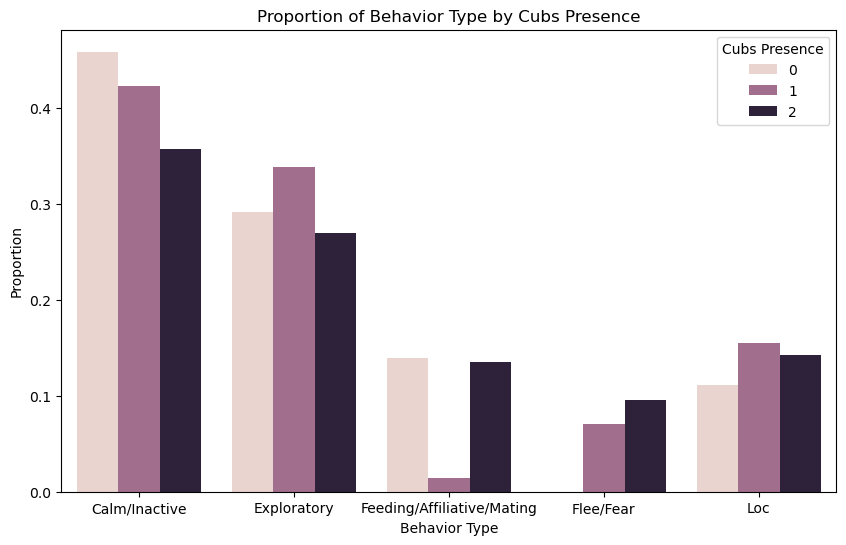

In [9]:
# 4. ADVANCED SOCIAL CONTEXT VS BEHAVIOR TYPE
# ADVANCED SOCIAL CONTEXT:
# WITHOUT CUBS (=0), 
# PRIDE WITH CUBS BUT NOT PRESENT DURING THE TEST (=1),
# PRIDE WITH CUBS AND THEY'RE PRESENT DURING THE TEST (=2)

# Calculate the proportion of each behavior type within each Cubs_presence category
proportions = transformed_data.groupby(['Cubs_presence', 'behavior_type']).size().unstack(fill_value=0)
proportions = proportions.div(proportions.sum(axis=1), axis=0)

# Reset index for plotting
proportions = proportions.reset_index().melt(id_vars='Cubs_presence', var_name='behavior_type', value_name='proportion')

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=proportions, x='behavior_type', y='proportion', hue='Cubs_presence')

# Add labels and title
plt.xlabel('Behavior Type')
plt.ylabel('Proportion')
plt.title('Proportion of Behavior Type by Cubs Presence')

# Show plot
plt.legend(title='Cubs Presence')
plt.show()


# **Modeling**

In this section, we set up our models. The dependent variable is always the categorical 'behavior_type'.

**Baseline model**
   The first model is the baseline model, which includes only the binary predictor 'before_after'

   1. behavior_type ~ before_after

**Altitude**
   We model 'Altitude' together with the binary predictor 'before_after', for the 'before' values 'altitude' = 0

   2. behavior_type ~ before_after + before_after*altitude

   3. behavior_type ~ before_after + before_after*altitude + random factor 'Pride ID'

   extra 2.3 behavior_type ~ before_after + before_after*altitude (priors modified for Flee/Fear behavior)
   and 2.4 behavior_type (ONLY AFTER) ~ before_after*altitude

**Social context**
   To model the social context, we use the binary predictor 'Pride_with_cubs'

   4. behavior_type ~ before_after + Pride_with_cubs

**Advanced social context**
   To model the advanced social context, we use  the categorical predictor 'Cubs_presence'

   5. behavior_type ~ before_after + Cubs_presence

**Social/Advanced social context + altitude**
   Here we model together 'Pride_with_cubs' and 'Cubs_presence' with 'Altitude' variable

   6. behavior_type ~ before_after + Pride_with_cubs + before_after*altitude

   7. behavior_type ~ before_after + Cubs_presence + before_after*altitude

   

## **Baseline model**

In [6]:
# 1 BEHAVIOR_TYPE ~ BEFORE_AFTER

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure binary predictor
transformed_data['before_after'] = transformed_data['before_after'].astype(int)

# Build model
model1 = bmb.Model('behavior_type ~ before_after', data=transformed_data, family='categorical')

# Fit once with fixed settings (no while-loop "optimizing" ESS)
results1 = model1.fit(
    chains=4,
    cores=4,
    draws=2000,        # post-tune draws per chain
    tune=2000,         # warmup
    target_accept=0.9, # optionally raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary1 = az.summary(results1)
n_chains = results1.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary1)

issues = summary1[
    (summary1["ess_bulk"] < ess_threshold) |
    (summary1["ess_tail"] < ess_threshold) |
    (summary1["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional additional checks to inform reparameterization / model review
    try:
        n_divergences = int(results1.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


                              mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept[Calm/Inactive]     1.637  0.314   1.047    2.223      0.005   
Intercept[Exploratory]       0.353  0.373  -0.327    1.070      0.006   
Intercept[Flee/Fear]        -2.849  1.144  -5.033   -0.907      0.019   
Intercept[Loc]               0.093  0.394  -0.672    0.822      0.006   
before_after[Calm/Inactive] -0.553  0.434  -1.414    0.218      0.007   
before_after[Exploratory]    1.061  0.476   0.158    1.929      0.007   
before_after[Flee/Fear]      2.897  1.195   0.694    5.069      0.019   
before_after[Loc]            0.335  0.518  -0.649    1.312      0.008   

                             mcse_sd  ess_bulk  ess_tail  r_hat  
Intercept[Calm/Inactive]       0.004    4288.0    4747.0    1.0  
Intercept[Exploratory]         0.004    4415.0    4759.0    1.0  
Intercept[Flee/Fear]           0.019    4233.0    3434.0    1.0  
Intercept[Loc]                 0.004    4568.0    5515.0    1.0  
before_after

## **Altitude**

In [7]:
# 2 BEHAVIOR_TYPE ~ BEFORE_AFTER + BEFORE_AFTER*ALTITUDE

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
# Optional: ensure altitude variable is numeric (adjust variable name if needed)
# transformed_data['z_log_altitude'] = pd.to_numeric(transformed_data['z_log_altitude'], errors='coerce')

# Build model
model2 = bmb.Model(
    'behavior_type ~ before_after + before_after:z_log_altitude',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings (no while-loop to "optimize" ESS)
results2 = model2.fit(
    chains=4,
    cores=4,
    draws=1000,        # post-tune draws per chain
    tune=1000,         # warmup
    target_accept=0.9, # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary2 = az.summary(results2)
n_chains = results2.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary2)

issues = summary2[
    (summary2["ess_bulk"] < ess_threshold) |
    (summary2["ess_tail"] < ess_threshold) |
    (summary2["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results2.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, before_after:z_log_altitude]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                             mean     sd  hdi_3%  hdi_97%  \
Intercept[Calm/Inactive]                    1.637  0.315   1.091    2.256   
Intercept[Exploratory]                      0.355  0.376  -0.360    1.057   
Intercept[Flee/Fear]                       -2.833  1.105  -5.074   -1.013   
Intercept[Loc]                              0.089  0.397  -0.620    0.855   
before_after[Calm/Inactive]                -0.527  0.424  -1.339    0.258   
before_after[Exploratory]                   1.094  0.472   0.232    1.996   
before_after[Flee/Fear]                     2.847  1.155   0.797    4.992   
before_after[Loc]                           0.360  0.514  -0.608    1.335   
before_after:z_log_altitude[Calm/Inactive]  0.004  0.322  -0.590    0.593   
before_after:z_log_altitude[Exploratory]   -0.130  0.307  -0.735    0.399   
before_after:z_log_altitude[Flee/Fear]     -0.434  0.378  -1.163    0.244   
before_after:z_log_altitude[Loc]           -0.099  0.354  -0.767    0.546   

In [10]:
# EXTRA
# 2.3 BEHAVIOR_TYPE ~ BEFORE_AFTER + BEFORE_AFTER*ALTITUDE
# PRIORS MODIFIED FOR FLEE/FEAR

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
# Optional: ensure altitude variable is numeric
# transformed_data['z_log_altitude'] = pd.to_numeric(transformed_data['z_log_altitude'], errors='coerce')

# Define custom priors (ensure the term and class name match your model terms exactly)
priors = {
    'before_after:z_log_altitude[Flee/Fear]': bmb.Prior('Normal', mu=-0.5, sigma=0.2)
}

# Create the model with custom priors
model3 = bmb.Model(
    'behavior_type ~ before_after + before_after:z_log_altitude',
    data=transformed_data,
    family='categorical',
    priors=priors
)

# Fit once with fixed settings (no while-loop to "optimize" ESS)
results3 = model3.fit(
    chains=4,
    cores=4,
    draws=1000,        # post-tune draws per chain
    tune=1000,         # warmup
    target_accept=0.9, # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary3 = az.summary(results3)
n_chains = results3.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary3)

issues = summary3[
    (summary3["ess_bulk"] < ess_threshold) |
    (summary3["ess_tail"] < ess_threshold) |
    (summary3["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results3.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, before_after:z_log_altitude]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 634 seconds.


                                             mean     sd  hdi_3%  hdi_97%  \
Intercept[Calm/Inactive]                    1.641  0.311   1.089    2.251   
Intercept[Exploratory]                      0.356  0.377  -0.379    1.026   
Intercept[Flee/Fear]                       -2.836  1.129  -5.074   -0.945   
Intercept[Loc]                              0.098  0.400  -0.620    0.855   
before_after[Calm/Inactive]                -0.540  0.421  -1.349    0.252   
before_after[Exploratory]                   1.081  0.475   0.217    2.018   
before_after[Flee/Fear]                     2.836  1.179   0.797    5.048   
before_after[Loc]                           0.338  0.516  -0.612    1.327   
before_after:z_log_altitude[Calm/Inactive]  0.004  0.319  -0.589    0.580   
before_after:z_log_altitude[Exploratory]   -0.124  0.305  -0.689    0.441   
before_after:z_log_altitude[Flee/Fear]     -0.432  0.376  -1.163    0.253   
before_after:z_log_altitude[Loc]           -0.095  0.352  -0.806    0.516   

In [8]:
# 3 BEHAVIOR_TYPE ~ BEFORE_AFTER + BEFORE_AFTER*ALTITUDE + RANDOM FACTOR PRIDE ID

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['prides'] = transformed_data['prides'].astype('category')
# Optional: ensure altitude variable is numeric
# transformed_data['z_log_altitude'] = pd.to_numeric(transformed_data['z_log_altitude'], errors='coerce')

# Build model with random intercept for prides
model4 = bmb.Model(
    'behavior_type ~ before_after + before_after:z_log_altitude + ( 1 + before_after | prides)',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings (no while-loop to "optimize" ESS)
results4 = model4.fit(
    chains=4,
    cores=4,
    draws=1000,        # post-tune draws per chain
    tune=1000,         # warmup
    target_accept=0.95, # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary4 = az.summary(results4)
n_chains = results4.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary4)

issues = summary4[
    (summary4["ess_bulk"] < ess_threshold) |
    (summary4["ess_tail"] < ess_threshold) |
    (summary4["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results4.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, before_after:z_log_altitude, 1|prides_sigma, 1|prides_offset, before_after|prides_sigma, before_after|prides_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


                                              mean     sd  hdi_3%  hdi_97%  \
Intercept[Calm/Inactive]                     1.616  0.418   0.804    2.361   
Intercept[Exploratory]                       0.454  0.468  -0.443    1.315   
Intercept[Flee/Fear]                        -2.900  1.144  -4.992   -0.803   
Intercept[Loc]                               0.151  0.476  -0.731    1.025   
before_after[Calm/Inactive]                 -0.535  0.473  -1.457    0.295   
before_after[Exploratory]                    1.173  0.508   0.248    2.137   
before_after[Flee/Fear]                      2.795  1.179   0.751    5.079   
before_after[Loc]                            0.413  0.554  -0.656    1.432   
before_after:z_log_altitude[Calm/Inactive]   0.020  0.314  -0.570    0.593   
before_after:z_log_altitude[Exploratory]    -0.131  0.299  -0.661    0.452   
before_after:z_log_altitude[Flee/Fear]      -0.471  0.375  -1.196    0.208   
before_after:z_log_altitude[Loc]            -0.105  0.351  -0.79

In [12]:
# EXTRA
# 2.4 BEHAVIOR_TYPE ~ ALTITUDE

# Keep only after=1 and work on a copy to avoid SettingWithCopy warnings
transformed_data1 = transformed_data.loc[transformed_data['before_after'] == 1].copy()

# Ensure categorical target with desired order
transformed_data1['behavior_type'] = transformed_data1['behavior_type'].astype('category')
transformed_data1['behavior_type'] = transformed_data1['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data1['before_after'] = transformed_data1['before_after'].astype(int)
# Optional: ensure altitude variable is numeric
# transformed_data1['z_log_altitude'] = pd.to_numeric(transformed_data1['z_log_altitude'], errors='coerce')

# Build model
model = bmb.Model('behavior_type ~ z_log_altitude', data=transformed_data1, family='categorical')

# Fit once with fixed settings (no while-loop to "optimize" ESS)
results = model.fit(
    chains=4,
    cores=4,
    draws=1000,        # post-tune draws per chain
    tune=1000,         # warmup
    target_accept=0.9, # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary = az.summary(results)
n_chains = results.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary)

issues = summary[
    (summary["ess_bulk"] < ess_threshold) |
    (summary["ess_tail"] < ess_threshold) |
    (summary["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, z_log_altitude]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 636 seconds.


                                mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept[Calm/Inactive]       1.078  0.290   0.539    1.616      0.007   
Intercept[Exploratory]         1.416  0.280   0.889    1.945      0.007   
Intercept[Flee/Fear]          -0.010  0.368  -0.720    0.653      0.009   
Intercept[Loc]                 0.418  0.324  -0.180    1.055      0.008   
z_log_altitude[Calm/Inactive]  0.023  0.315  -0.577    0.613      0.009   
z_log_altitude[Exploratory]   -0.109  0.304  -0.667    0.468      0.008   
z_log_altitude[Flee/Fear]     -0.414  0.363  -1.077    0.279      0.009   
z_log_altitude[Loc]           -0.080  0.350  -0.738    0.572      0.009   

                               mcse_sd  ess_bulk  ess_tail  r_hat  
Intercept[Calm/Inactive]         0.005    1569.0    1981.0    1.0  
Intercept[Exploratory]           0.005    1586.0    2037.0    1.0  
Intercept[Flee/Fear]             0.006    1737.0    2217.0    1.0  
Intercept[Loc]                   0.005    1786.0    

## **Social context**

In [9]:
# 4 BEHAVIOR_TYPE ~ BEFORE_AFTER + PRIDE_WITH_CUBS

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['Pride_with_cubs'] = transformed_data['Pride_with_cubs'].astype(int)

# Build model
model5 = bmb.Model(
    'behavior_type ~ before_after + Pride_with_cubs',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings
results5 = model5.fit(
    chains=4,
    cores=4,
    draws=1000,        # post-tune draws per chain
    tune=1000,         # warmup
    target_accept=0.9, # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary5 = az.summary(results5)
n_chains = results5.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary5)

issues = summary5[
    (summary5["ess_bulk"] < ess_threshold) |
    (summary5["ess_tail"] < ess_threshold) |
    (summary5["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results5.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, Pride_with_cubs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                 mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept[Calm/Inactive]        1.518  0.422   0.710    2.295      0.008   
Intercept[Exploratory]          0.104  0.480  -0.791    0.997      0.009   
Intercept[Flee/Fear]           -8.347  3.212 -14.324   -3.144      0.080   
Intercept[Loc]                 -0.397  0.563  -1.549    0.597      0.010   
before_after[Calm/Inactive]    -0.555  0.423  -1.318    0.259      0.009   
before_after[Exploratory]       1.071  0.467   0.189    1.910      0.010   
before_after[Flee/Fear]         2.870  1.188   0.831    5.077      0.025   
before_after[Loc]               0.330  0.503  -0.619    1.263      0.011   
Pride_with_cubs[Calm/Inactive]  0.193  0.450  -0.632    1.035      0.009   
Pride_with_cubs[Exploratory]    0.358  0.473  -0.524    1.236      0.009   
Pride_with_cubs[Flee/Fear]      5.938  3.017   1.166   11.594      0.074   
Pride_with_cubs[Loc]            0.673  0.564  -0.391    1.740      0.010   

           

## **Advanced social context**

In [10]:
# 5 BEHAVIOR_TYPE ~ BEFORE_AFTER + CUBS_PRESENCE

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['Cubs_presence'] = transformed_data['Cubs_presence'].astype('category')

# Build model
model6 = bmb.Model(
    'behavior_type ~ before_after + Cubs_presence',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings
results6 = model6.fit(
    chains=4,
    cores=4,
    draws=1000,         # post-tune draws per chain
    tune=1000,          # warmup
    target_accept=0.9,  # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary6 = az.summary(results6)
n_chains = results6.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary6)

issues = summary6[
    (summary6["ess_bulk"] < ess_threshold) |
    (summary6["ess_tail"] < ess_threshold) |
    (summary6["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results6.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, Cubs_presence]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept[Calm/Inactive]         1.530  0.432   0.708    2.343      0.009   
Intercept[Exploratory]           0.115  0.491  -0.830    1.010      0.009   
Intercept[Flee/Fear]            -6.696  2.180 -10.816   -2.912      0.054   
Intercept[Loc]                  -0.375  0.559  -1.445    0.640      0.010   
before_after[Calm/Inactive]     -0.516  0.433  -1.360    0.257      0.008   
before_after[Exploratory]        1.124  0.480   0.225    2.021      0.009   
before_after[Flee/Fear]          2.894  1.210   0.911    5.230      0.025   
before_after[Loc]                0.365  0.530  -0.650    1.323      0.010   
Cubs_presence[Calm/Inactive, 1]  2.128  1.017   0.348    4.014      0.029   
Cubs_presence[Calm/Inactive, 2] -0.281  0.475  -1.206    0.570      0.010   
Cubs_presence[Exploratory, 1]    2.369  1.032   0.489    4.288      0.030   
Cubs_presence[Exploratory, 2]   -0.182  0.506  -1.133    0.760      0.010   

## **Social/Advanced social context + altitude**

In [11]:
# 6 BEHAVIOR_TYPE ~ BEFORE_AFTER + PRIDE_WITH_CUBS + BEFORE_AFTER*ALTITUDE

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['Pride_with_cubs'] = transformed_data['Pride_with_cubs'].astype(int)
# Optional: ensure altitude variable is numeric
# transformed_data['z_log_altitude'] = pd.to_numeric(transformed_data['z_log_altitude'], errors='coerce')

# Build model
model7 = bmb.Model(
    'behavior_type ~ before_after + Pride_with_cubs + before_after:z_log_altitude',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings
results7 = model7.fit(
    chains=4,
    cores=4,
    draws=1000,         # post-tune draws per chain
    tune=1000,          # warmup
    target_accept=0.9,  # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary7 = az.summary(results7)
n_chains = results7.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary7)

issues = summary7[
    (summary7["ess_bulk"] < ess_threshold) |
    (summary7["ess_tail"] < ess_threshold) |
    (summary7["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results7.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, Pride_with_cubs, before_after:z_log_altitude]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                             mean     sd  hdi_3%  hdi_97%  \
Intercept[Calm/Inactive]                    1.528  0.431   0.708    2.328   
Intercept[Exploratory]                      0.094  0.495  -0.798    1.031   
Intercept[Flee/Fear]                       -8.478  3.172 -14.634   -3.402   
Intercept[Loc]                             -0.413  0.573  -1.491    0.633   
before_after[Calm/Inactive]                -0.539  0.432  -1.329    0.277   
before_after[Exploratory]                   1.090  0.471   0.234    2.006   
before_after[Flee/Fear]                     2.832  1.188   0.702    5.023   
before_after[Loc]                           0.342  0.526  -0.668    1.294   
Pride_with_cubs[Calm/Inactive]              0.187  0.459  -0.688    1.021   
Pride_with_cubs[Exploratory]                0.388  0.486  -0.495    1.292   
Pride_with_cubs[Flee/Fear]                  6.078  2.976   1.485   11.714   
Pride_with_cubs[Loc]                        0.710  0.588  -0.371    1.808   

In [12]:
# 7 BEHAVIOR_TYPE ~ BEFORE_AFTER + CUBS_PRESENCE + BEFORE_AFTER*ALTITUDE

# Ensure categorical target with desired order
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

# Ensure predictors' types
transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['Cubs_presence'] = transformed_data['Cubs_presence'].astype('category')
# Optional: ensure altitude variable is numeric
# transformed_data['z_log_altitude'] = pd.to_numeric(transformed_data['z_log_altitude'], errors='coerce')

# Build model
model8 = bmb.Model(
    'behavior_type ~ before_after + Cubs_presence + before_after:z_log_altitude',
    data=transformed_data,
    family='categorical'
)

# Fit once with fixed settings
results8 = model8.fit(
    chains=4,
    cores=4,
    draws=1000,         # post-tune draws per chain
    tune=1000,          # warmup
    target_accept=0.9,  # raise to 0.95 if you see divergences
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary8 = az.summary(results8)
n_chains = results8.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary8)

issues = summary8[
    (summary8["ess_bulk"] < ess_threshold) |
    (summary8["ess_tail"] < ess_threshold) |
    (summary8["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results8.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, before_after, Cubs_presence, before_after:z_log_altitude]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


                                             mean     sd  hdi_3%  hdi_97%  \
Intercept[Calm/Inactive]                    1.527  0.435   0.737    2.370   
Intercept[Exploratory]                      0.087  0.501  -0.889    1.008   
Intercept[Flee/Fear]                       -6.848  2.181 -10.791   -2.892   
Intercept[Loc]                             -0.406  0.579  -1.532    0.631   
before_after[Calm/Inactive]                -0.484  0.438  -1.243    0.386   
before_after[Exploratory]                   1.161  0.478   0.285    2.033   
before_after[Flee/Fear]                     2.879  1.190   0.640    5.041   
before_after[Loc]                           0.393  0.525  -0.655    1.315   
Cubs_presence[Calm/Inactive, 1]             2.041  0.964   0.339    3.876   
Cubs_presence[Calm/Inactive, 2]            -0.287  0.483  -1.196    0.648   
Cubs_presence[Exploratory, 1]               2.321  0.977   0.493    4.106   
Cubs_presence[Exploratory, 2]              -0.153  0.511  -1.112    0.792   

# **Model comparison**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/opt/miniconda3/envs/lion_models/lib/pytho

                                                    rank    elpd_loo  \
Before/After + Cubs presence                           0 -365.320348   
Before/After + Pride with cubs                         1 -366.106362   
Before/After + Cubs presence + Before/After x A...     2 -367.673945   
Before/After + Pride with cubs + Before/After x...     3 -368.596408   
Before/After                                           4 -368.777498   
Before/After + Altitude + (1|Pride ID)                 5 -370.482277   
Before/After + Before/After x Altitude                 6 -371.890228   

                                                        p_loo  elpd_diff  \
Before/After + Cubs presence                        16.338765   0.000000   
Before/After + Pride with cubs                      11.781148   0.786015   
Before/After + Cubs presence + Before/After x A...  20.540629   2.353597   
Before/After + Pride with cubs + Before/After x...  16.128226   3.276060   
Before/After                               

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/opt/miniconda3/envs/lion_models/lib/pytho

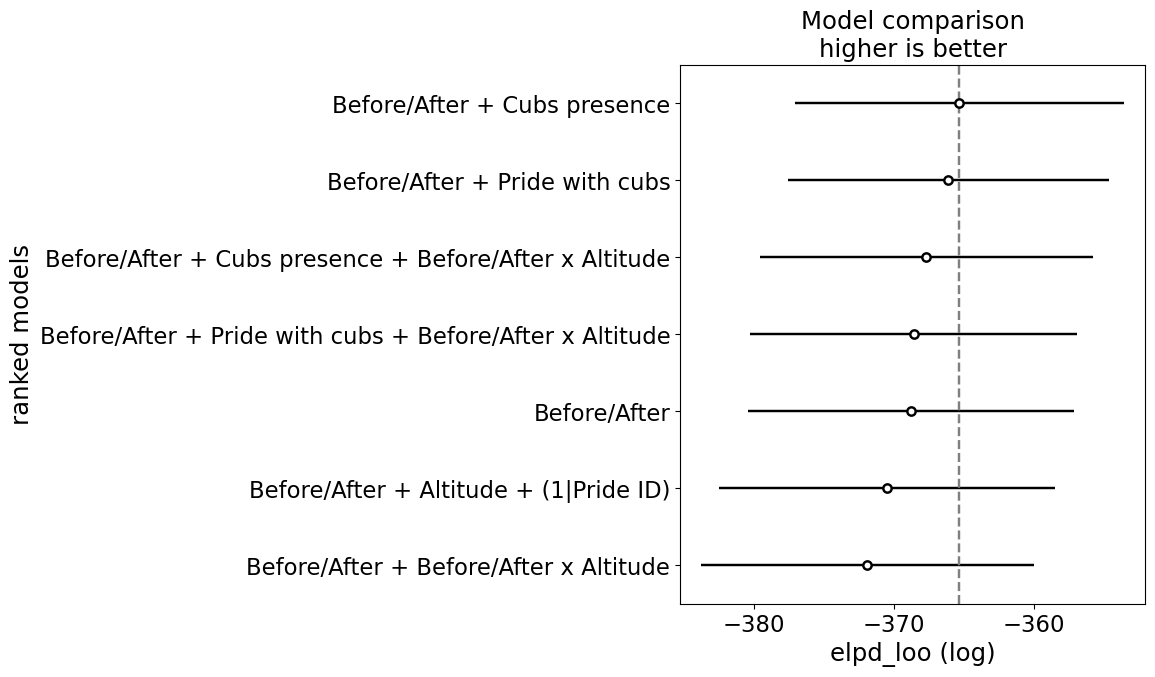

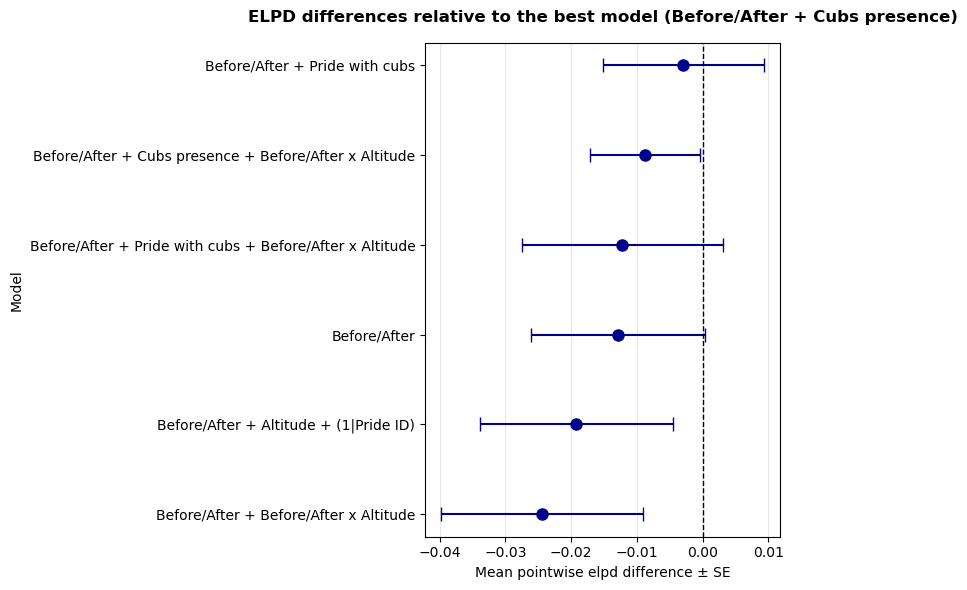

In [14]:
model_dict = {
    "Before/After": results1,
    "Before/After + Before/After x Altitude": results2,
    "Before/After + Altitude + (1|Pride ID)": results4,
    "Before/After + Pride with cubs": results5,
    "Before/After + Cubs presence": results6,
    "Before/After + Pride with cubs + Before/After x Altitude": results7,
    "Before/After + Cubs presence + Before/After x Altitude": results8
}

# Compare the models
comparison = az.compare(model_dict)

# Print the comparison results
print(comparison)

# Optionally, visualize the comparison
az.plot_compare(comparison)
plt.savefig('comparison_plot_Tolerance.png', bbox_inches='tight')

loo_dict = {
    name: az.loo(idata, pointwise=True)
    for name, idata in model_dict.items()
}
ref_name = "Before/After + Cubs presence"
loo_ref = loo_dict[ref_name].loo_i

diff_df = pd.DataFrame()
for name, loo_obj in loo_dict.items():
    if name == ref_name:
        continue
    diff_df[name] = loo_obj.loo_i - loo_ref

summary = diff_df.apply(
    lambda col: pd.Series({
        "mean": np.mean(col),
        "se": np.std(col) / np.sqrt(len(col))
    })
).T

summary_sorted = summary.copy()
summary_sorted["abs_mean"] = summary_sorted["mean"].abs()
summary_sorted = summary_sorted.sort_values("abs_mean", ascending=False)


plt.figure(figsize=(8, 6))

plt.errorbar(
    x=summary_sorted["mean"],
    y=summary_sorted.index,
    xerr=summary_sorted["se"],
    fmt="o",
    capsize=5,
    markersize=8,
    linestyle="None",
    color="darkblue"
)

# Vertical reference line
plt.axvline(0, color="black", linestyle="--", lw=1)

plt.xlabel("Mean pointwise elpd difference ± SE")
plt.ylabel("Model")
plt.title(f"ELPD differences relative to the best model ({ref_name})", fontweight="bold",
    pad=15)

plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(
    "loo_difference_overall_Tolerance_horizontal_sorted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46906/499226467.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


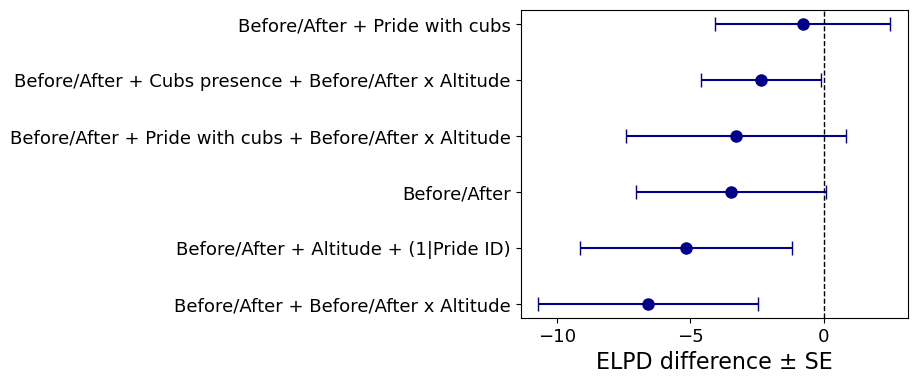

In [16]:
from matplotlib.ticker import MultipleLocator

# ------------------------
# Overall ELPD difference ± SE per model
# ------------------------
summary = diff_df.apply(
    lambda col: pd.Series({
        "elpd_diff": col.sum(),                          # ΔELPD
        "se": np.sqrt(np.sum((col - col.mean())**2))     # SE(ΔELPD)
    })
).T

# Sort models by absolute ΔELPD (furthest from 0 first)
summary_sorted = summary.copy()
summary_sorted["abs_elpd"] = summary_sorted["elpd_diff"].abs()
summary_sorted = summary_sorted.sort_values("abs_elpd", ascending=False)

# ------------------------
# Plot
# ------------------------
plt.figure(figsize=(5, 4))
ax = plt.gca()


plt.errorbar(
    x=summary_sorted["elpd_diff"],
    y=summary_sorted.index,
    xerr=summary_sorted["se"],
    fmt="o",
    capsize=5,
    markersize=8,
    linestyle="None",
    color="darkblue"
)

# Vertical reference line
ax.axvline(0, color="black", linestyle="--", lw=1)

# X-axis ticks every 1.0
ax.xaxis.set_major_locator(MultipleLocator(5.0))
ax.tick_params(axis='both', labelsize=13)
ax.set_xlabel("ELPD difference ± SE", fontsize=16)

plt.tight_layout()
plt.savefig(
    "loo_ELPD_difference_overall_Tolerance_reviewed.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# **Posterior distribution best models**

### **Model 5 + observed vs predicted data plot**

array([[<Axes: title={'center': 'Intercept\nCalm/Inactive'}>,
        <Axes: title={'center': 'Intercept\nExploratory'}>,
        <Axes: title={'center': 'Intercept\nFlee/Fear'}>,
        <Axes: title={'center': 'Intercept\nLoc'}>],
       [<Axes: title={'center': 'before_after\nCalm/Inactive'}>,
        <Axes: title={'center': 'before_after\nExploratory'}>,
        <Axes: title={'center': 'before_after\nFlee/Fear'}>,
        <Axes: title={'center': 'before_after\nLoc'}>],
       [<Axes: title={'center': 'Cubs_presence\nCalm/Inactive, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nCalm/Inactive, 2'}>,
        <Axes: title={'center': 'Cubs_presence\nExploratory, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nExploratory, 2'}>],
       [<Axes: title={'center': 'Cubs_presence\nFlee/Fear, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nFlee/Fear, 2'}>,
        <Axes: title={'center': 'Cubs_presence\nLoc, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nLoc, 2'}>]],

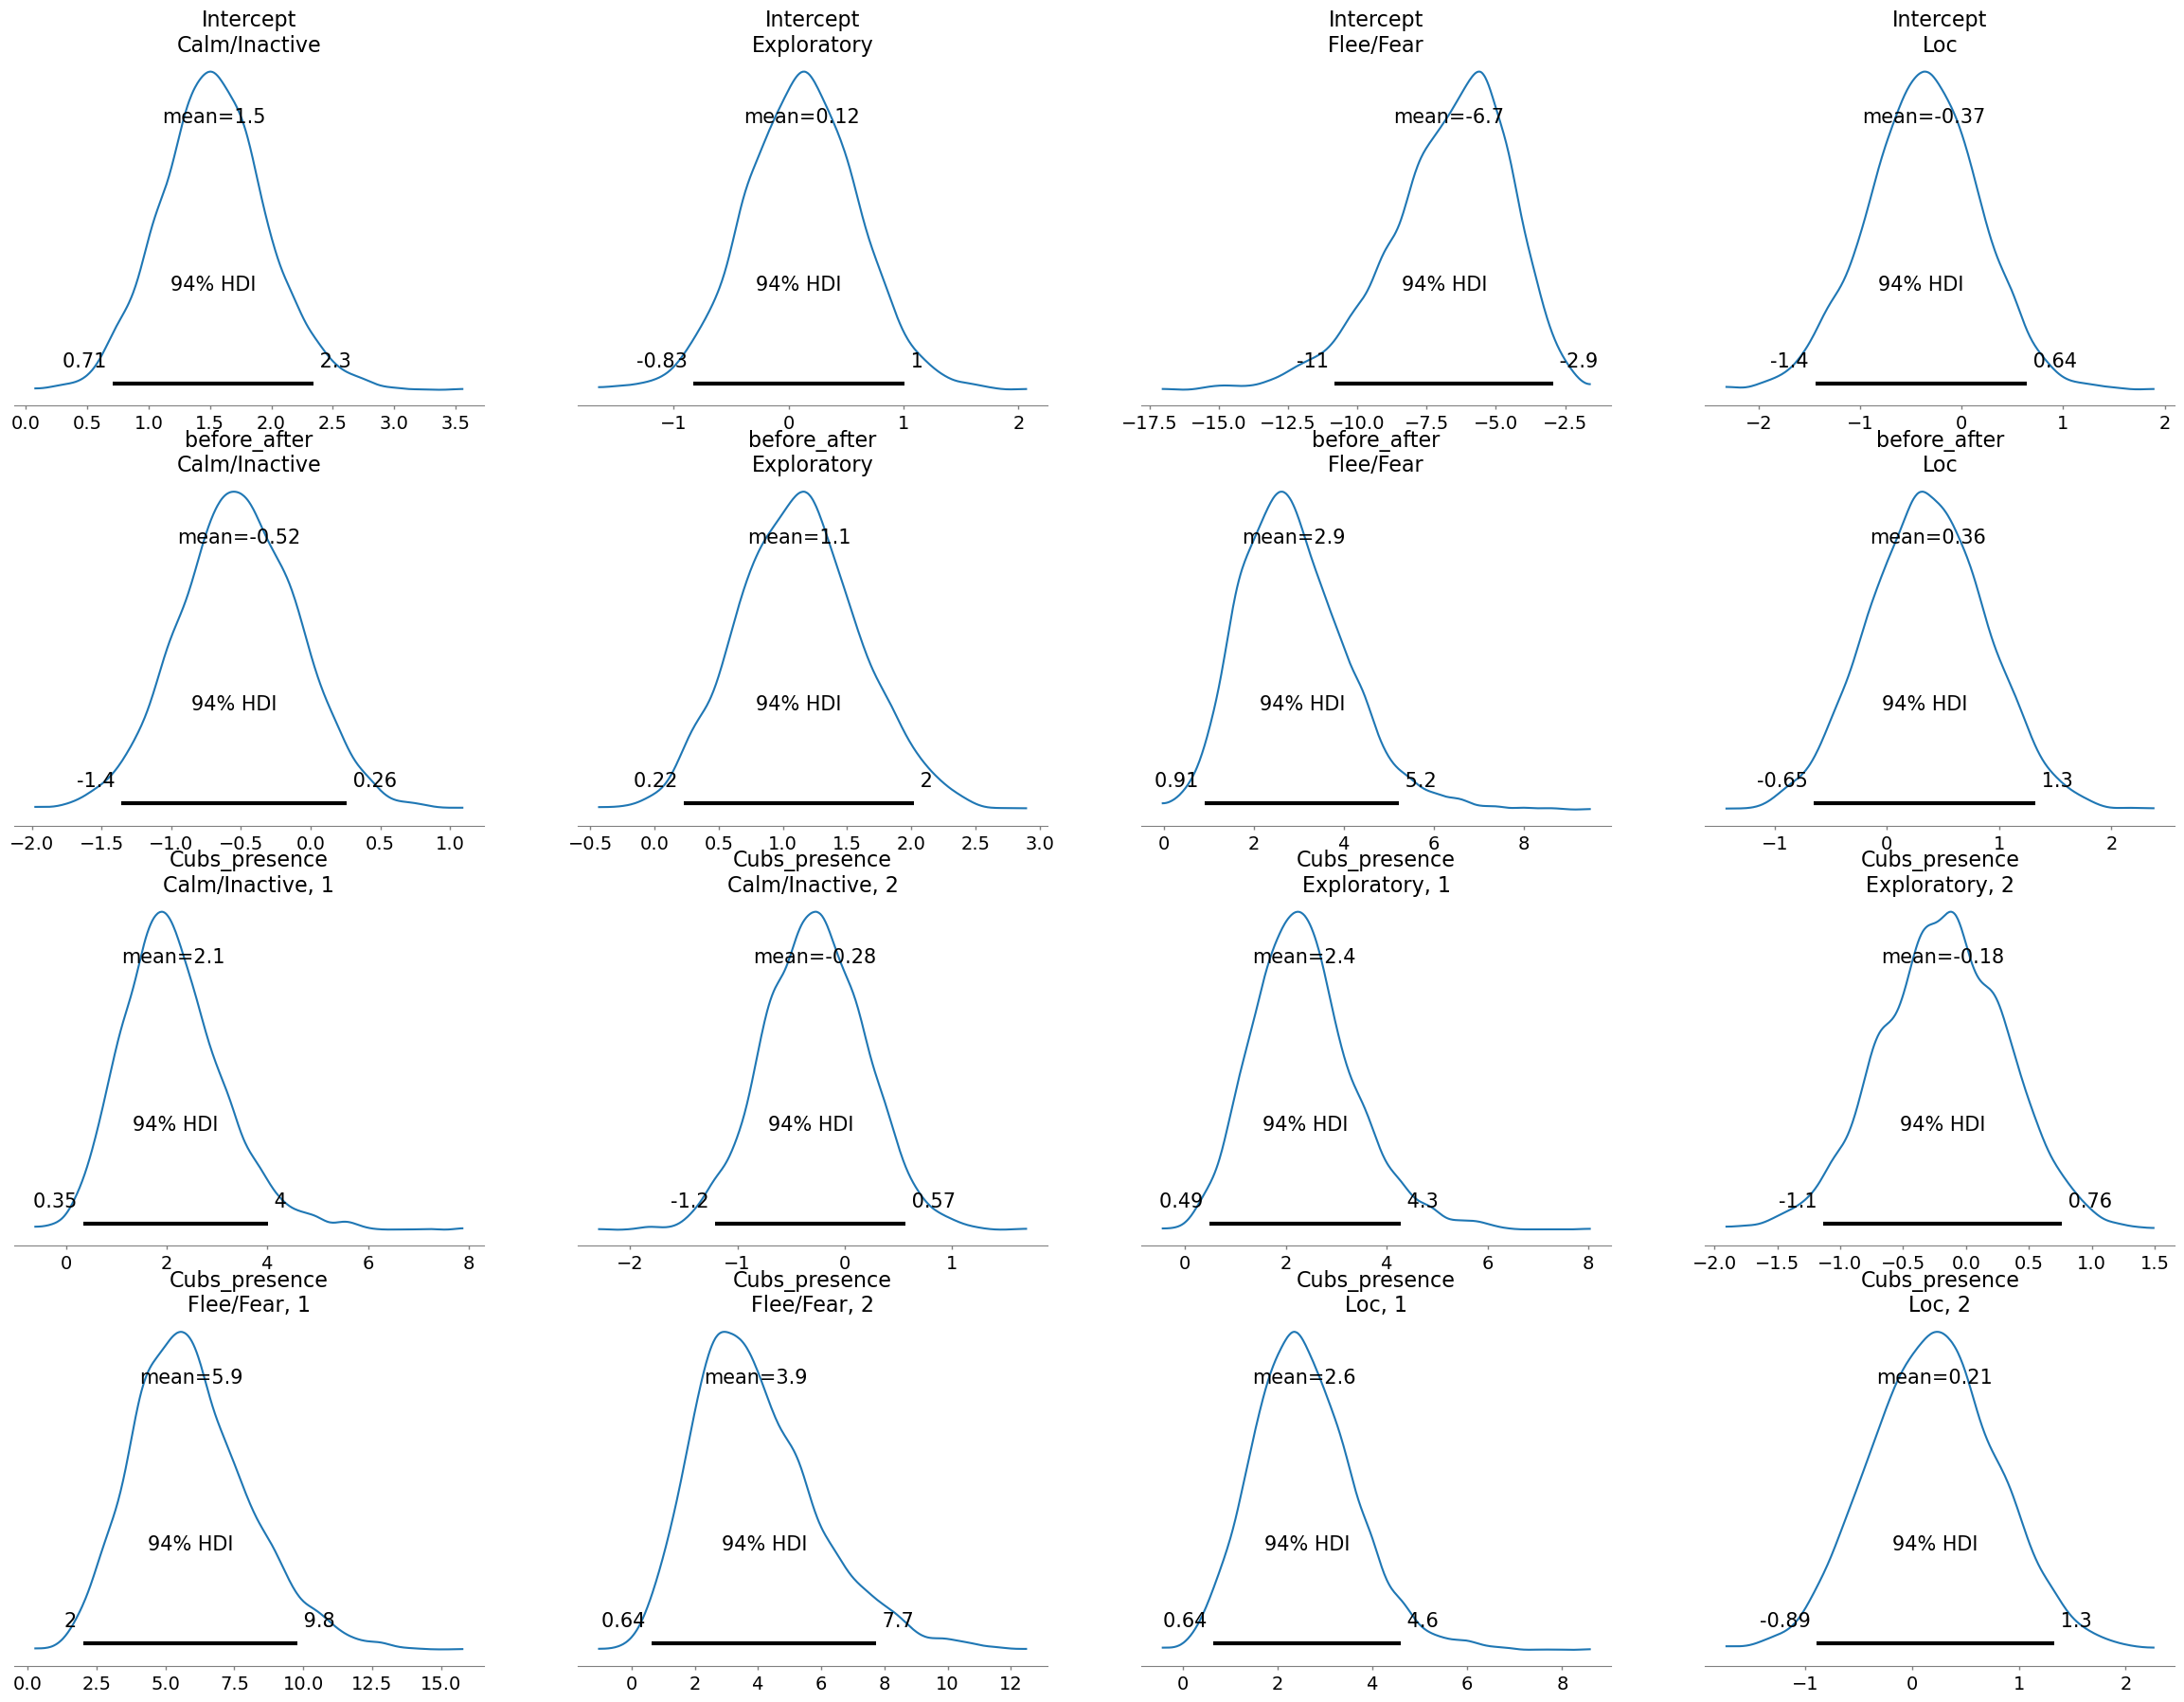

In [17]:
az.plot_posterior(results6)

In [18]:
# Print the structure of the inference data
print(results6)

# Alternatively, use the repr function for a more detailed view
repr(results6)
# Access the observed_data group
observed_data = results6.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 4kB
Dimensions:        (__obs__: 269)
Coordinates:
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 263 264 265 266 267 268
Data variables:
    behavior_type  (__obs__) int64 2kB 3 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2
Attributes:
    created_at:                  2026-02-11T11:56:51.037455+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='behavior_type'>

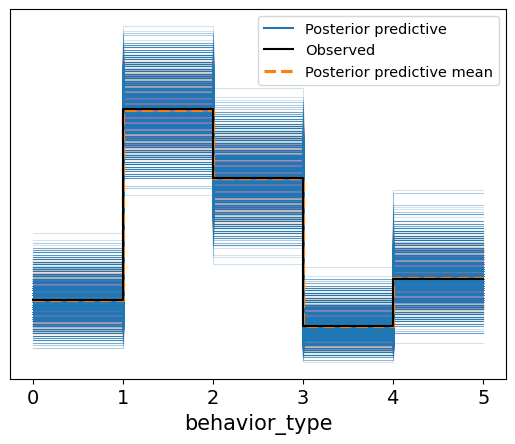

In [19]:
# Generate posterior predictive samples
posterior_predictive = model6.predict(results6, kind="pps")

# Add the posterior predictive samples to the inference data
#results6.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results6, data_pairs={"behavior_type": "behavior_type"})

In [21]:
from matplotlib.lines import Line2D

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46906/870867686.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['before_after', 'Cubs_presence', 'behavior_type'])
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46906/870867686.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed['prop'] = observed.groupby(['before_after', 'Cubs_presence'])['count']\


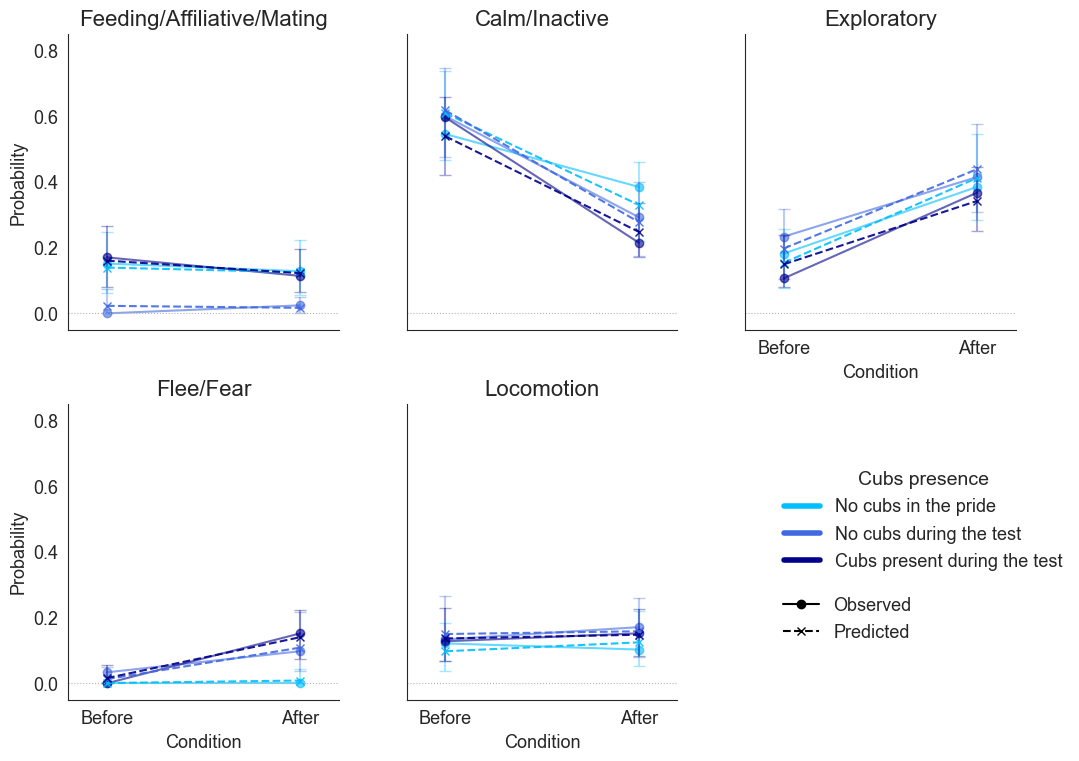

In [56]:
# ============================================================
# UPDATED CLEAN PUBLICATION-READY PLOT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Global styling
# ------------------------------------------------------------
sns.set_style("white")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 14
})

# ------------------------------------------------------------
# Color palette
# ------------------------------------------------------------
palette = {0: 'deepskyblue', 1: 'royalblue', 2: 'darkblue'}

# ------------------------------------------------------------
# Ensure categorical ordering
# ------------------------------------------------------------
transformed_data['behavior_type'] = transformed_data['behavior_type'].astype('category')
transformed_data['behavior_type'] = transformed_data['behavior_type'].cat.reorder_categories(
    ['Feeding/Affiliative/Mating', 'Calm/Inactive', 'Exploratory', 'Flee/Fear', 'Loc'],
    ordered=True
)

transformed_data['before_after'] = transformed_data['before_after'].astype(int)
transformed_data['Cubs_presence'] = transformed_data['Cubs_presence'].astype('category')

# ------------------------------------------------------------
# Predictor grid
# ------------------------------------------------------------
ba_levels = sorted(transformed_data['before_after'].unique())
cubs_levels = transformed_data['Cubs_presence'].cat.categories

pred_grid = pd.DataFrame([
    {'before_after': ba, 'Cubs_presence': cubs}
    for ba in ba_levels for cubs in cubs_levels
])

# ------------------------------------------------------------
# Posterior probabilities + 95% CI
# ------------------------------------------------------------
idata_prob = model6.predict(results6, data=pred_grid, kind="mean", inplace=False)
post = idata_prob.posterior

for v in ("p", "probabilities", "mu", "y_hat"):
    if v in post.data_vars:
        varname = v
        break
else:
    raise KeyError(f"Could not find probability variable in {list(post.data_vars)}")

p = post[varname]

obs_dim = "__obs__" if "__obs__" in p.dims else next(d for d in p.dims if d in ("obs","observation","obs_id"))
cat_dim = "behavior_type_dim" if "behavior_type_dim" in p.dims else next(d for d in p.dims if d not in ("chain","draw",obs_dim))

p_s = p.stack(sample=("chain", "draw"))

categories = transformed_data['behavior_type'].cat.categories
if cat_dim in p_s.coords and set(categories).issubset(set(p_s.coords[cat_dim].values)):
    coord_vals = list(p_s.coords[cat_dim].values)
    idx_of = lambda cat: coord_vals.index(cat)
else:
    idx_of = lambda cat: categories.get_loc(cat)

pred_list = []
for i, row in pred_grid.iterrows():
    for cat in categories:
        j = idx_of(cat)
        probs = np.clip(p_s.isel({obs_dim: i, cat_dim: j}).values, 0, 1)

        pred_list.append({
            'before_after': row['before_after'],
            'Cubs_presence': row['Cubs_presence'],
            'behavior_type': cat,
            'pred_prob': float(np.mean(probs)),
            'ci_lower': float(np.quantile(probs, 0.025)),
            'ci_upper': float(np.quantile(probs, 0.975)),
        })

pred_probs = pd.DataFrame(pred_list)

# ------------------------------------------------------------
# Observed proportions
# ------------------------------------------------------------
observed = (
    transformed_data
    .groupby(['before_after', 'Cubs_presence', 'behavior_type'])
    .size()
    .reset_index(name='count')
)

observed['prop'] = observed.groupby(['before_after', 'Cubs_presence'])['count']\
    .transform(lambda x: x / x.sum())

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------
plot_data = pd.merge(
    observed,
    pred_probs,
    on=['before_after', 'Cubs_presence', 'behavior_type'],
    how='left'
)

plot_data['before_after_label'] = plot_data['before_after'].map({0: "Before", 1: "After"})

# ------------------------------------------------------------
# Facet grid (slightly larger panels)
# ------------------------------------------------------------
g = sns.FacetGrid(
    plot_data,
    col="behavior_type",
    col_wrap=3,
    height=3.8,     # increased size
    aspect=1.1,
    sharey=True
)

def plot_obs_pred_ci(data, **kwargs):
    ax = plt.gca()

    for cubs in sorted(data['Cubs_presence'].unique(), key=lambda v: int(v)):
        d = data[data['Cubs_presence'] == cubs].sort_values('before_after')
        color = palette[int(cubs)]

        # Observed
        ax.plot(
            d['before_after_label'],
            d['prop'],
            marker='o',
            linestyle='-',
            color=color,
            alpha=0.6
        )

        # Predicted
        ax.plot(
            d['before_after_label'],
            d['pred_prob'],
            marker='x',
            linestyle='--',
            color=color,
            alpha=0.9,
            zorder=3
        )

        # CI
        lower = np.minimum(d['ci_lower'], d['pred_prob'])
        upper = np.maximum(d['ci_upper'], d['pred_prob'])
        yerr = np.vstack([d['pred_prob'] - lower, upper - d['pred_prob']])

        ax.errorbar(
            d['before_after_label'],
            d['pred_prob'],
            yerr=yerr,
            fmt='none',
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            alpha=0.35,
            zorder=2
        )

    ax.axhline(0, color='0.7', linestyle=':', linewidth=0.8)
    ax.set_xlim(-0.2, 1.2)

g.map_dataframe(plot_obs_pred_ci)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------
g.set(ylim=(-0.05, 0.85))
g.set_axis_labels("Condition", "Probability")

# Make x-axis label slightly smaller
for ax in g.axes.flatten():
    ax.xaxis.label.set_size(13)
    ax.yaxis.label.set_size(13)

# ------------------------------------------------------------
# Clean titles
# ------------------------------------------------------------
for ax in g.axes.flatten():
    title = ax.get_title().split('=')[-1].strip()
    title = "Locomotion" if title == "Loc" else title
    ax.set_title(title)

# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------
color_handles = [
    Line2D([0], [0], color=palette[int(c)], lw=4)
    for c in cubs_levels
]

color_labels = [
    "No cubs in the pride",
    "No cubs during the test",
    "Cubs present during the test"
]

marker_handles = [
    Line2D([0], [0], color='black', marker='o', linestyle='-', label="Observed"),
    Line2D([0], [0], color='black', marker='x', linestyle='--', label="Predicted")
]

fig = g.fig

legend1 = fig.legend(
    color_handles,
    color_labels,
    loc="center right",
    title='Cubs presence',
    bbox_to_anchor=(0.85, 0.3),
    frameon=False
)

legend2 = fig.legend(
    marker_handles,
    ["Observed", "Predicted"],
    loc="center right",
    bbox_to_anchor=(0.73, 0.17),
    frameon=False
)

# ------------------------------------------------------------
# Title & spacing
# ------------------------------------------------------------

plt.subplots_adjust(
    right=0.80,
    wspace=0.25,
    hspace=0.25
)

plt.savefig("observed_vs_predicted_reviewed.png", dpi=300, bbox_inches="tight")
plt.show()


<xarray.Dataset> Size: 4MB
Dimensions:        (chain: 2, draw: 1000, __obs__: 271)
Coordinates:
  * chain          (chain) int64 16B 0 1
  * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 265 266 267 268 269 270
Data variables:
    behavior_type  (chain, draw, __obs__) int64 4MB 2 1 1 1 4 1 ... 2 3 2 1 1 2
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


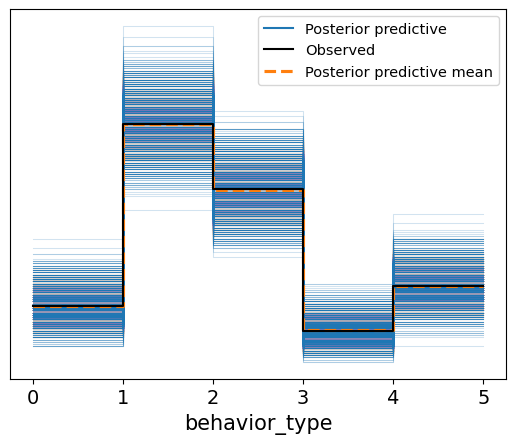

In [78]:
# Check the structure of the posterior_predictive group
print(results6.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results6, data_pairs={"behavior_type": "behavior_type"})
plt.savefig('pp_model4.1.png', bbox_inches='tight')

### **Model 4**

array([[<Axes: title={'center': 'Intercept\nCalm/Inactive'}>,
        <Axes: title={'center': 'Intercept\nExploratory'}>,
        <Axes: title={'center': 'Intercept\nFlee/Fear'}>],
       [<Axes: title={'center': 'Intercept\nLoc'}>,
        <Axes: title={'center': 'before_after\nCalm/Inactive'}>,
        <Axes: title={'center': 'before_after\nExploratory'}>],
       [<Axes: title={'center': 'before_after\nFlee/Fear'}>,
        <Axes: title={'center': 'before_after\nLoc'}>,
        <Axes: title={'center': 'Pride_with_cubs\nCalm/Inactive'}>],
       [<Axes: title={'center': 'Pride_with_cubs\nExploratory'}>,
        <Axes: title={'center': 'Pride_with_cubs\nFlee/Fear'}>,
        <Axes: title={'center': 'Pride_with_cubs\nLoc'}>]], dtype=object)

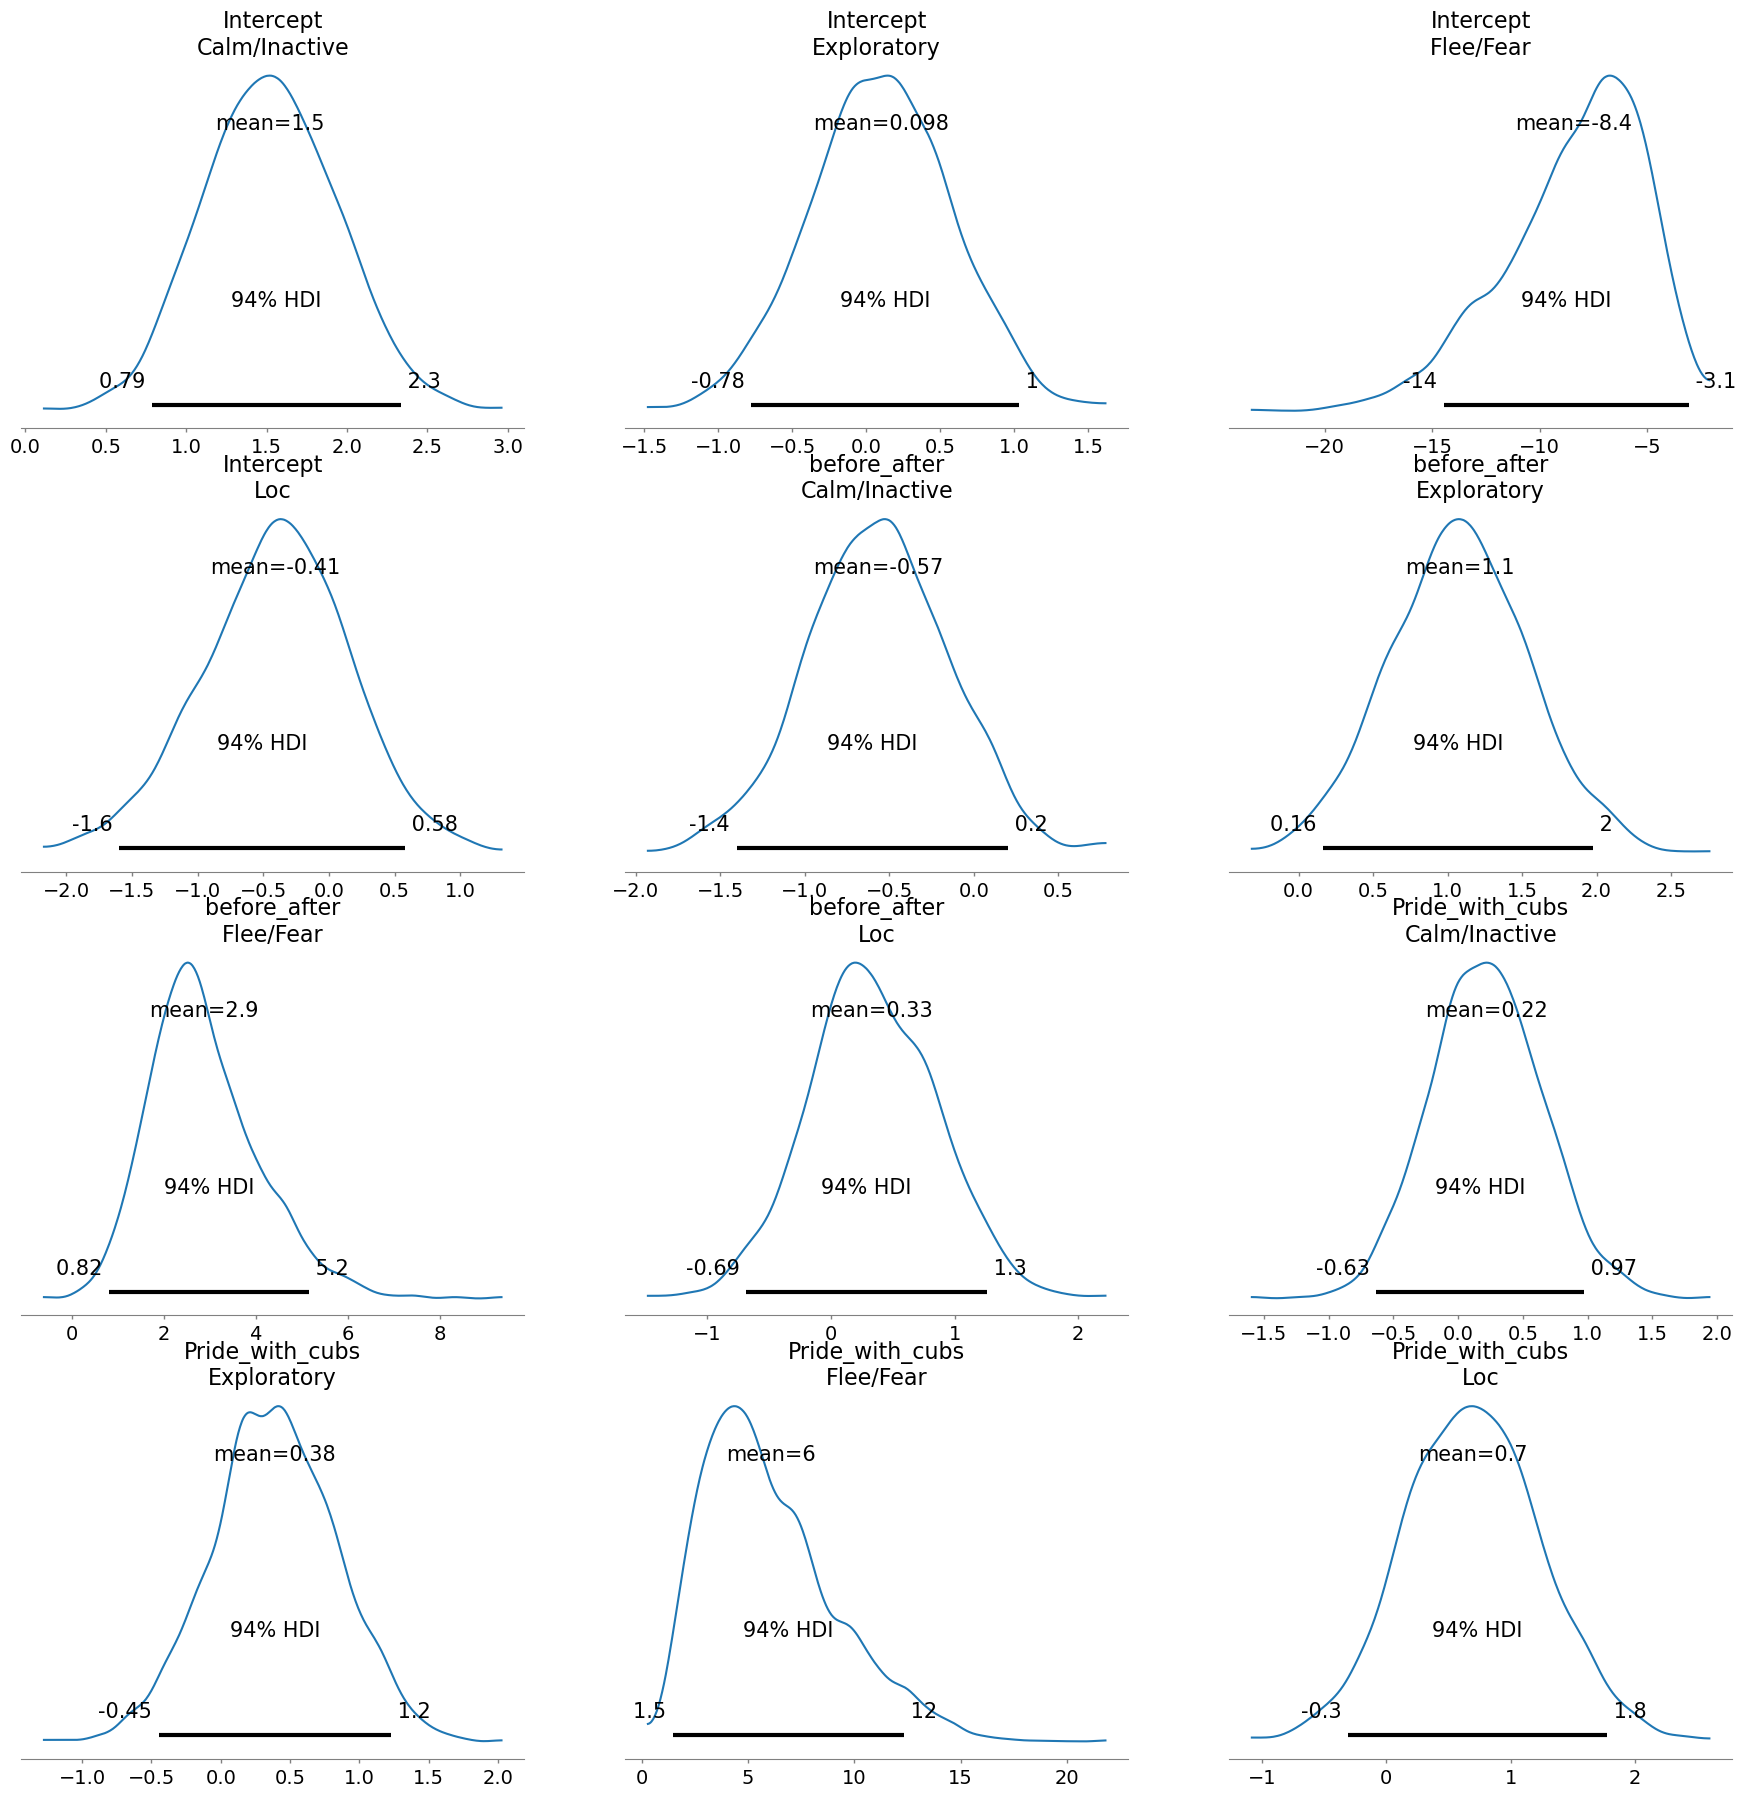

In [67]:
az.plot_posterior(results5)

In [68]:
# Print the structure of the inference data
print(results5)

# Alternatively, use the repr function for a more detailed view
repr(results5)
# Access the observed_data group
observed_data = results5.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 4kB
Dimensions:        (__obs__: 271)
Coordinates:
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 265 266 267 268 269 270
Data variables:
    behavior_type  (__obs__) int64 2kB 3 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2
Attributes:
    created_at:                  2025-07-29T10:31:12.214609
    arviz_version:               0.17.1
    inference_library:           pymc
    inference_library_version:   5.23.0
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [69]:
# Generate posterior predictive samples
posterior_predictive = model5.predict(results5, kind="pps")

# Add the posterior predictive samples to the inference data
results5.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results5, data_pairs={"behavior_type": "behavior_type"})

/Users/elenaiannino/miniconda3/lib/python3.11/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 4MB
Dimensions:        (chain: 2, draw: 1000, __obs__: 271)
Coordinates:
  * chain          (chain) int64 16B 0 1
  * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 265 266 267 268 269 270
Data variables:
    behavior_type  (chain, draw, __obs__) int64 4MB 2 2 1 0 1 1 ... 3 4 4 3 2 2
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


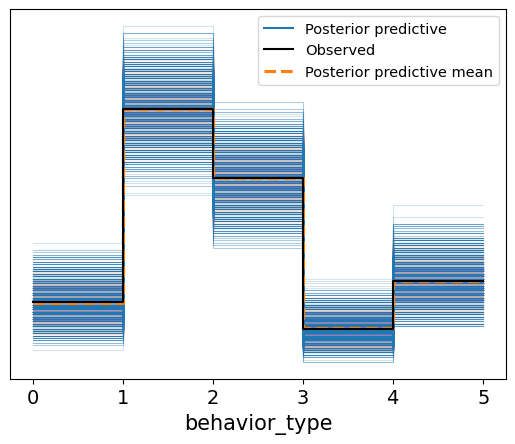

In [79]:
# Check the structure of the posterior_predictive group
print(results5.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results5, data_pairs={"behavior_type": "behavior_type"})
plt.savefig('pp_model3.1.png', bbox_inches='tight')

### **Model 7**

array([[<Axes: title={'center': 'Intercept\nCalm/Inactive'}>,
        <Axes: title={'center': 'Intercept\nExploratory'}>,
        <Axes: title={'center': 'Intercept\nFlee/Fear'}>,
        <Axes: title={'center': 'Intercept\nLoc'}>],
       [<Axes: title={'center': 'before_after\nCalm/Inactive'}>,
        <Axes: title={'center': 'before_after\nExploratory'}>,
        <Axes: title={'center': 'before_after\nFlee/Fear'}>,
        <Axes: title={'center': 'before_after\nLoc'}>],
       [<Axes: title={'center': 'Cubs_presence\nCalm/Inactive, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nCalm/Inactive, 2'}>,
        <Axes: title={'center': 'Cubs_presence\nExploratory, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nExploratory, 2'}>],
       [<Axes: title={'center': 'Cubs_presence\nFlee/Fear, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nFlee/Fear, 2'}>,
        <Axes: title={'center': 'Cubs_presence\nLoc, 1'}>,
        <Axes: title={'center': 'Cubs_presence\nLoc, 2'}>],


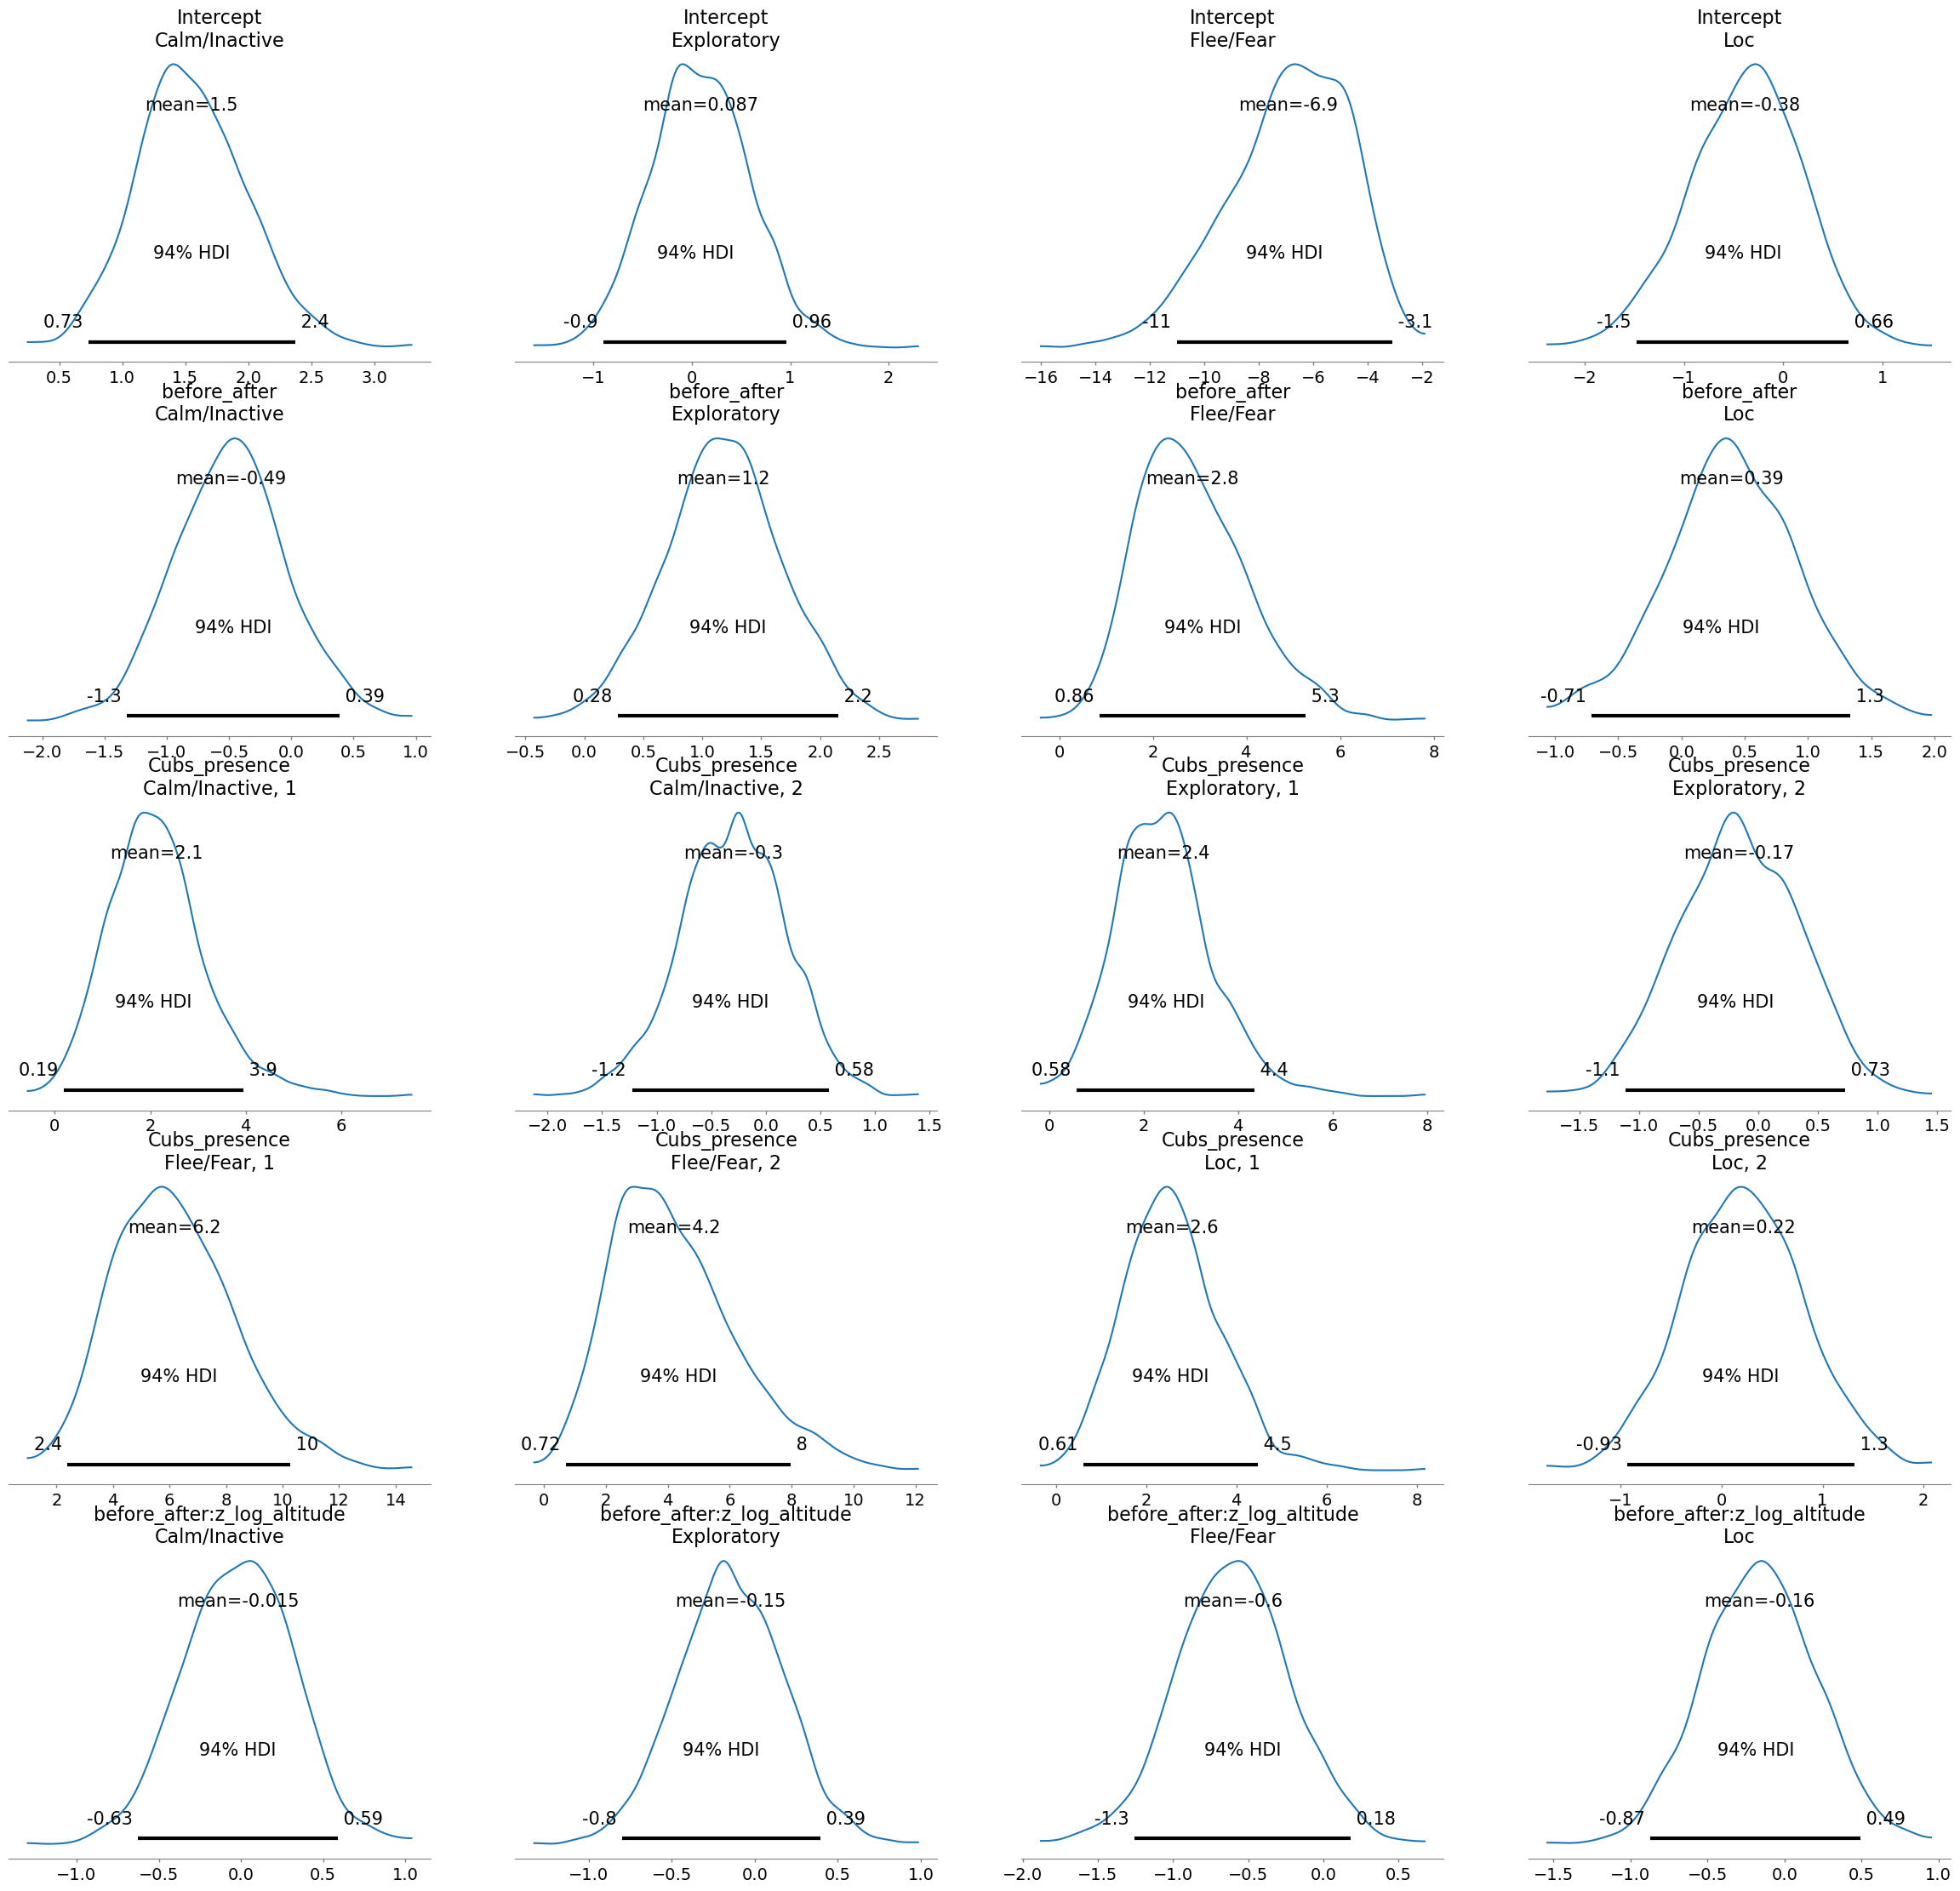

In [71]:
az.plot_posterior(results8)

In [72]:
# Print the structure of the inference data
print(results8)

# Alternatively, use the repr function for a more detailed view
repr(results8)
# Access the observed_data group
observed_data = results8.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 4kB
Dimensions:        (__obs__: 271)
Coordinates:
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 265 266 267 268 269 270
Data variables:
    behavior_type  (__obs__) int64 2kB 3 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2
Attributes:
    created_at:                  2025-07-29T10:52:31.993951
    arviz_version:               0.17.1
    inference_library:           pymc
    inference_library_version:   5.23.0
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [73]:
# Generate posterior predictive samples
posterior_predictive = model8.predict(results8, kind="pps")

# Add the posterior predictive samples to the inference data
results8.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results8, data_pairs={"behavior_type": "behavior_type"})

/Users/elenaiannino/miniconda3/lib/python3.11/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 4MB
Dimensions:        (chain: 2, draw: 1000, __obs__: 271)
Coordinates:
  * chain          (chain) int64 16B 0 1
  * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * __obs__        (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 265 266 267 268 269 270
Data variables:
    behavior_type  (chain, draw, __obs__) int64 4MB 1 1 1 0 1 0 ... 2 2 2 4 2 2
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


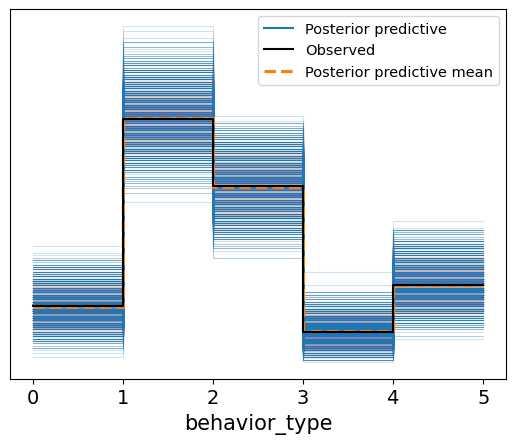

In [80]:
# Check the structure of the posterior_predictive group
print(results8.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results8, data_pairs={"behavior_type": "behavior_type"})
plt.savefig('pp_model5.2.png', bbox_inches='tight')